# Data Wrangling sobre datos de compras públicas del Perú

### Radar de Oportunidades en Compras Públicas

**Curso:** Lenguaje de Ciencia de Datos II (4364) · Unidad 2 · CIBERTEC · Ciclo 4 · 2026

**Grupo 4:** Danilo Colman Mernes · Cristopher Risco Uchofe · Rolan Fabrizio Jauregui · Paola Vergara

---

## Qué hace este notebook

Aplica las técnicas de transformación y gobernanza de datos sobre el dataset del proyecto: las adjudicaciones del Estado peruano publicadas en estándar OCDS por el SEACE, más el registro de proveedores del OECE. 
El recorrido va de datos crudos a una señal ordenable, en cinco etapas:

| Etapa | Pregunta que responde | Módulo del proyecto |
|:---|:---|:---|
| **1. Calidad de datos** | ¿En qué estado llegan los datos? | `calidad.py` |
| **2. Enriquecimiento interno** | ¿Qué información hay escondida en lo que ya tenemos? | `transformacion.py` |
| **3. Normalización y escalado** | ¿Cómo se comparan magnitudes de escalas distintas? | `transformacion.py` |
| **4. Validación automatizada** | ¿Cómo evitamos que un dato malo llegue al tablero? | `validacion.py` |
| **5. Optimización** | ¿Cómo se procesa esto sin desperdiciar recursos? | `utils.py` |

## Cómo está construido

Las funciones no están escritas en las celdas: viven en los módulos que el pipeline ejecuta en producción. El notebook los importa y muestra su resultado paso a paso.

La razón es de mantenimiento. Si el código estuviera duplicado, cualquier corrección en el pipeline dejaría al notebook mostrando algo que ya no es cierto. Donde hace falta ver la lógica, la celda la imprime con `inspect.getsource()`.

## Nota sobre vectorización

Ninguna función de la ruta de datos itera fila por fila. No hay un solo `iterrows()`, `itertuples()` ni `apply(axis=1)` en los módulos del pipeline: todo se resuelve con operaciones sobre columnas completas, máscaras booleanas y `groupby`. La sección 6 incluye una auditoría que lo verifica sobre el código fuente.

---
# 0. Preparación del entorno

Se importan las librerías y los módulos del proyecto, y se define el formato visual que usarán todas las tablas del notebook.

In [1]:
# ── Ruta del proyecto ────────────────────────────────────────────────────────
# El notebook debe vivir en la misma carpeta que los .py del proyecto, porque
# importa sus módulos. Si se mueve, ajustar esta ruta.
import sys, os
RUTA_PROYECTO = os.path.abspath(".")
if RUTA_PROYECTO not in sys.path:
    sys.path.insert(0, RUTA_PROYECTO)

# ── Librerías ────────────────────────────────────────────────────────────────
import inspect
import json
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Módulos del proyecto ─────────────────────────────────────────────────────
import config
import calidad
import transformacion
import validacion
from utils import Reporte, optimizar_memoria

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

print(f"pandas   : {pd.__version__}")
print(f"numpy    : {np.__version__}")
print(f"Proyecto : {RUTA_PROYECTO}")
print(f"UIT {config.UIT_ANIO}  : S/ {config.UIT_SOLES:,}")

pandas   : 3.0.2
numpy    : 2.4.4
Proyecto : /home/claude/work
UIT 2026  : S/ 5,500


### Formato de las tablas

Todas las tablas del notebook se muestran con `tabla()`, que centra los valores, resalta los encabezados y agrega separador de miles. Tener un solo lugar donde se define el formato evita que cada celda invente el suyo.

In [2]:
# ── Paleta del proyecto ──────────────────────────────────────────────────────
AZUL    = "#0D3B66"   # encabezados y barras principales
AZUL_2  = "#1D6FA4"
VERDE   = "#00A878"   # valores correctos / después de optimizar
NARANJA = "#FF6B35"   # valores a revisar / antes de optimizar
GRIS    = "#F7F9FC"   # filas alternas


def tabla(df, titulo=None, decimales=2, ancho_col=None):
    """Devuelve el DataFrame con formato uniforme para presentación.

    Centra los valores, resalta la fila de encabezados sobre fondo azul,
    alterna el color de las filas y aplica separador de miles. Se usa en todas
    las tablas del notebook para que el formato sea consistente y esté
    definido en un solo lugar.
    """
    estilos = [
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-size", "1.02em"),
                   ("font-weight", "700"), ("color", AZUL),
                   ("text-align", "left"), ("padding", "6px 4px 10px 4px")]},
        {"selector": "th.col_heading",
         "props": [("background-color", AZUL), ("color", "white"),
                   ("text-align", "center"), ("padding", "9px 12px"),
                   ("font-weight", "600"), ("border", "none")]},
        {"selector": "th.row_heading",
         "props": [("background-color", GRIS), ("color", AZUL),
                   ("text-align", "left"), ("padding", "7px 12px"),
                   ("font-weight", "600")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "7px 12px"),
                   ("border-bottom", "1px solid #E6EBF2")]},
        {"selector": "tbody tr:nth-child(even) td",
         "props": [("background-color", GRIS)]},
        {"selector": "",
         "props": [("border-collapse", "collapse"), ("font-size", "0.92em")]},
    ]
    if ancho_col:
        estilos.append({"selector": "td, th",
                        "props": [("max-width", ancho_col),
                                  ("white-space", "normal")]})

    estilo = (df.style
              .format(precision=decimales, thousands=",", na_rep="—")
              .set_table_styles(estilos))
    if titulo:
        estilo = estilo.set_caption(titulo)
    return estilo


def barra_color(df, columna, titulo=None, decimales=2, color=AZUL_2):
    """Como tabla(), más una barra de fondo proporcional en una columna.

    Sirve para que la magnitud relativa se lea de un vistazo sin tener que
    comparar números mentalmente.
    """
    return tabla(df, titulo, decimales).bar(
        subset=[columna], color=color + "55", vmin=0)


NOMBRE_MES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
              "Jul", "Ago", "Set", "Oct", "Nov", "Dic"]

print("Formato de tablas definido.")

Formato de tablas definido.


---
# 1. Los datos del proyecto

## Qué se va a hacer

Cargar los tres datasets que produce la etapa de ingesta y mirar su forma antes de tocarlos.

| Dataset | Grano | Origen |
|:---|:---|:---|
| `ocds_procesos` | una fila por ítem adjudicado | Descarga masiva OCDS/SEACE |
| `demanda_por_categoria` | una fila por categoría CUBSO | Agregación del anterior |
| `densidad_proveedores` | una fila por categoría CUBSO | Adjudicatarios + registro OECE |

Si alguna ruta no existe, hay que correr antes el pipeline:

```
python ingesta_ocds.py
python diccionario_cubso.py
python consulta_proveedores.py
```

In [3]:
faltan = [p.name for p in (config.PARQUET_OCDS, config.PARQUET_DEMANDA,
                           config.PARQUET_DENSIDAD) if not p.exists()]
if faltan:
    raise FileNotFoundError(f"Faltan insumos: {faltan}. Correr el pipeline primero.")

ocds     = pd.read_parquet(config.PARQUET_OCDS)
demanda  = pd.read_parquet(config.PARQUET_DEMANDA)
densidad = pd.read_parquet(config.PARQUET_DENSIDAD)

resumen_carga = pd.DataFrame([
    {"Dataset": "ocds_procesos", "Grano": "ítem adjudicado",
     "Filas": len(ocds), "Columnas": ocds.shape[1]},
    {"Dataset": "demanda_por_categoria", "Grano": "categoría CUBSO",
     "Filas": len(demanda), "Columnas": demanda.shape[1]},
    {"Dataset": "densidad_proveedores", "Grano": "categoría CUBSO",
     "Filas": len(densidad), "Columnas": densidad.shape[1]},
]).set_index("Dataset")

tabla(resumen_carga, "Datasets cargados", decimales=0)

,Grano,Filas,Columnas
Dataset,,,
ocds_procesos,ítem adjudicado,"228,012",15
demanda_por_categoria,categoría CUBSO,"30,709",3
densidad_proveedores,categoría CUBSO,"30,701",12


**Qué muestra.** El primer dataset es el detalle: cada fila es un ítem que el Estado adjudicó a un proveedor. Los otros dos ya están agregados por categoría CUBSO, que es el nivel al que trabaja el radar.

La diferencia de filas entre `demanda_por_categoria` y `densidad_proveedores` no es un error: hay categorías con monto adjudicado cuyo proveedor no quedó identificado en la fuente, y esas no entran en el conteo de densidad.

In [4]:
tabla(ocds.head(4), "Detalle OCDS — primeras filas", ancho_col="170px")

,ocid,fecha,entidad,metodo_contratacion,tipo_objeto,cubso_id,cubso_descripcion,descripcion_item,monto_adjudicado,moneda,estado_award,proveedor_id,proveedor_nombre,n_proveedores_award,anio
0,ocds-dgv273-seacev3-2021-10015-47,2024-12-13 15:15:54.831622+00:00,PROGRAMA SUBSECTORIAL DE IRRIGACIONES - PSI,Procedimiento Especial de Contratación,works,7212120300233023,CONSTRUCCION DE CANALES DE RIEGO,"CONTRATACIÓN PARA LA ELABORACION DE EXPEDIENTE TECNICO Y EJECUCION DE OBRA: REHABILITACION DE LA BOCATOMA TONGORRAPE, DISTRITO DE MOTUPE, PROVINCIA DE LAMBAYEQUE, DEPARTAMENTO DE LAMBAYEQUE.","2,817,369.90",PEN,—,PE-RUC-464375,CONSORCIO CRUZ DE MOTUPE,1,"2,024"
1,ocds-dgv273-seacev3-2021-10189-40,2024-06-25 17:11:57.103895+00:00,PROGRAMA EDUCACION BASICA PARA TODOS UE 026,Adjudicación Simplificada,services,8312170300375952,SERVICIO DE LINEA DEDICADA A INTERNET DE 70 MBPS,CONTRATACIÓN DEL SERVICIO DE INTERNET LÍNEA DEDICADA PARA EL COLEGIO MAYOR SECUNDARIO PRESIDENTE DEL PERÚ COAR LIMA,"220,000.00",PEN,—,PE-RUC-20524671876,P & P BUSINESS GROUP S.A.C.,1,"2,024"
2,ocds-dgv273-seacev3-2021-10194-33,2024-04-28 13:21:32.845530+00:00,INSTITUTO NACIONAL DE ENFERMEDADES NEOPLASICAS,Licitación Pública,goods,4229640800185594,VIDEOENDOSCOPIO,ADQUISICION DE VIDEOENDOSCOPIO ALTA PEDIATRICA,"1,181,107.00",PEN,—,PE-RUC-20108629909,CARDIO PERFUSION E.I.R.LTDA,1,"2,024"
3,ocds-dgv273-seacev3-2021-10231-130,2024-05-13 13:45:51.503230+00:00,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE DESCENTRALIZADO - PROVIAS DESCENTRALIZADO,Adjudicación Simplificada,services,8311160300232363,SERVICIO DE TELEFONIA MOVILES (CELULAR),SERVCIO DE TELEFONIA MOVIL,"290,160.00",PEN,—,PE-RUC-20467534026,AMERICA MOVIL PERU S.A.C.,1,"2,024"


**Qué muestra.** Las columnas que van a importar en todo el notebook:

- `cubso_descripcion` es la categoría del catálogo del Estado, y es la clave con la que se agrega todo.
- `monto_adjudicado` es la cifra en soles.
- `proveedor_id` viene con el prefijo del esquema OCDS (`PE-RUC-` seguido del número), detalle que reaparece en la métrica de validez.
- `fecha` se guardaba desde la ingesta pero no se usaba; la sección de enriquecimiento la aprovecha.

In [5]:
# Punto de partida del wrangling: el maestro integrado, ANTES de transformar.
# Se reconstruye en memoria porque el Parquet en disco ya guarda el maestro
# con las transformaciones aplicadas.
from diagnostico import construir_maestro

convocatorias = (pd.read_parquet(config.PARQUET_CONVOCATORIAS)
                 if config.PARQUET_CONVOCATORIAS.exists() else None)
maestro_crudo = construir_maestro(demanda, densidad, convocatorias)

print(f"Maestro sin transformar: {len(maestro_crudo):,} categorías "
      f"x {maestro_crudo.shape[1]} columnas\n")
tabla(maestro_crudo.head(3), "Maestro integrado, antes de transformar",
      ancho_col="140px")

Maestro sin transformar: 30,709 categorías x 19 columnas



,cubso_descripcion,demanda_soles,n_procesos,densidad_proveedores,n_adjudicaciones,n_procesos_con_adjudicacion,adjudicados,capitulo_rnp,habilitados_capitulo,ganadores_historicos,competencia_vigente,competencia_apta,salieron_del_registro,mercado_desierto,ticket_promedio,concentracion,convocatorias_vigentes,monto_vigente,accionable_hoy
0,SERVICIO DE SEGURIDAD Y VIGILANCIA,"8,156,077,001.64","1,818",624.00,"2,543.00","1,818.00",624.00,SERVICIOS,"40,089.00",426.00,333.00,323.00,93.00,False,"4,486,290.98",2.91,0,—,False
1,SERVICIO DE MANTENIMIENTO PERIODICO DE CARRETERAS,"7,621,208,619.04",402,405.00,432.00,402.00,405.00,SERVICIOS,"40,089.00",104.00,93.00,90.00,11.00,False,"18,958,230.40",0.99,0,—,False
2,CONSTRUCCION DE CARRETERA,"7,437,744,344.57",387,391.00,395.00,387.00,391.00,EJECUTOR_DE_OBRAS,"6,370.00",84.00,74.00,73.00,10.00,False,"19,218,977.63",0.99,0,—,False


**Qué muestra.** Este es el punto de partida del wrangling, con las dos fuentes de oferta integradas. Las columnas `capitulo_rnp` y `habilitados_capitulo` traen el conteo de habilitados por capítulo RNP, y `ganadores_historicos`, `competencia_vigente` y `salieron_del_registro` traen el cruce por RUC del detalle OCDS contra la Ficha Única del Proveedor: 48 981 RUC consultados, 0 fallidos, 43 203 habilitados vigentes.

`competencia_vigente` es la variable que ordena el radar. Contesta lo que ninguna de las dos fuentes contesta sola: de los proveedores que ganaron en esta categoría, cuántos siguen en condiciones de volver a competir.

El pipeline conserva un camino alternativo por concentración para las categorías que no llegan a cruzar con la ficha. Más adelante se ve para cuántas se usa.

---
# 2. Métricas de calidad de datos

## Qué se va a hacer

Medir el estado de los datos **antes** de transformarlos, con las seis métricas del Tema 3 aplicadas a las fuentes del proyecto.

| Métrica | Pregunta | Qué se comprueba acá |
|:---|:---|:---|
| **Completitud** | ¿Cuántos valores no son nulos? | Por columna y global, en las tres fuentes |
| **Unicidad** | ¿Hay registros duplicados? | Contra la clave de negocio, no contra la fila entera |
| **Validez** | ¿Los valores están en dominios permitidos? | Moneda, tipo de objeto, formato de RUC |
| **Consistencia** | ¿Se cumplen las reglas lógicas internas? | Monto sin categoría, adjudicación sin proveedor, año ≠ fecha |
| **Exactitud** | ¿Los valores son plausibles? | Cota fija de unidad más IQR de extremos |
| **Actualidad** | ¿Los datos están vigentes? | Desfase en días del registro más reciente |

## Dos decisiones de diseño

**Medir no es validar.** `calidad.py` mide y nunca rechaza una fila; `validacion.py` decide y corta el pipeline. Si la completitud de `monto_adjudicado` cayera del 98 % al 40 % de un mes a otro, la métrica lo mostraría aunque cada fila individual siguiera pasando el esquema.

**Ninguna métrica itera filas.** Todas se calculan con máscaras booleanas sobre columnas completas: `notna()`, `duplicated()`, `between()`, `isin()`. Sobre un detalle de cientos de miles de filas, un bucle de Python tardaría dos órdenes de magnitud más.

In [6]:
# Perfil de las tres fuentes. La clave de unicidad cambia con el grano: el
# detalle se identifica por proceso + categoría + proveedor; los agregados,
# por categoría.
perfil_ocds = calidad.perfil_completo(
    ocds, "ocds_procesos", ["ocid", "cubso_id", "proveedor_id"])
perfil_demanda = calidad.perfil_completo(
    demanda, "demanda_por_categoria", "cubso_descripcion")
perfil_densidad = calidad.perfil_completo(
    densidad, "densidad_proveedores", "cubso_descripcion")

# Cada perfil deja constancia en el log: una línea por métrica.
for p in (perfil_ocds, perfil_demanda, perfil_densidad):
    calidad.registrar_en_log(p)

resumen = calidad.resumen_tabular(
    [perfil_ocds, perfil_demanda, perfil_densidad]).set_index("dataset")
resumen.index.name = "Dataset"
resumen.columns = ["Filas", "Columnas", "Completitud %", "Unicidad %",
                   "Duplicados", "Reglas incumplidas", "Desfase (días)",
                   "Puntaje"]
barra_color(resumen, "Puntaje", "Calidad por fuente — resumen general")

2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=ocds_procesos | filas=228012 | puntaje=94.20


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=ocds_procesos | metrica=completitud | global=90.99% | columnas_incompletas=8


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=ocds_procesos | metrica=unicidad | unicidad=96.88% | duplicados=7113


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=ocds_procesos | metrica=validez | columna=moneda | validez=99.95% | fuera_dominio=107


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=ocds_procesos | metrica=validez | columna=tipo_objeto | validez=100.00% | fuera_dominio=0


...

2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=demanda_por_categoria | metrica=exactitud | columna=demanda_soles | exactitud=99.98% | atipicos_iqr=4969


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=densidad_proveedores | filas=30701 | puntaje=98.69


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=densidad_proveedores | metrica=completitud | global=97.37% | columnas_incompletas=4


2026-07-30 01:02:39 | INFO    | calidad | CALIDAD | dataset=densidad_proveedores | metrica=unicidad | unicidad=100.00% | duplicados=0


,Filas,Columnas,Completitud %,Unicidad %,Duplicados,Reglas incumplidas,Desfase (días),Puntaje
Dataset,,,,,,,,
ocds_procesos,"228,012",15,90.99,96.88,"7,113",1,210.00,94.20
demanda_por_categoria,"30,709",3,100.00,100.00,0,0,—,99.99
densidad_proveedores,"30,701",12,97.37,100.00,0,0,—,98.69


**Qué muestra.** El puntaje promedia las métricas expresables en porcentaje. No es un indicador científico y no conviene defenderlo como tal: sirve para comparar la misma fuente entre corridas y detectar degradación. Su valor está en la serie, no en el número aislado.

La fuente que más problemas acumula es el detalle OCDS, que es lo esperable: es el dato crudo tal como lo publican las entidades. Los agregados salen mejor porque el propio proceso de agregación descarta lo que no se puede sumar.

Las líneas de log que aparecen arriba son la evidencia de trazabilidad: una por métrica, con el resultado. El detalle completo por columna va al reporte JSON en `reports/`, no al log, porque un log registra eventos y no datos.

## 2.1 Completitud

Proporción de valores no nulos, por columna y global. Se calcula con `notna()`, que devuelve una matriz booleana del tamaño del DataFrame, promediada por columna en una sola pasada.

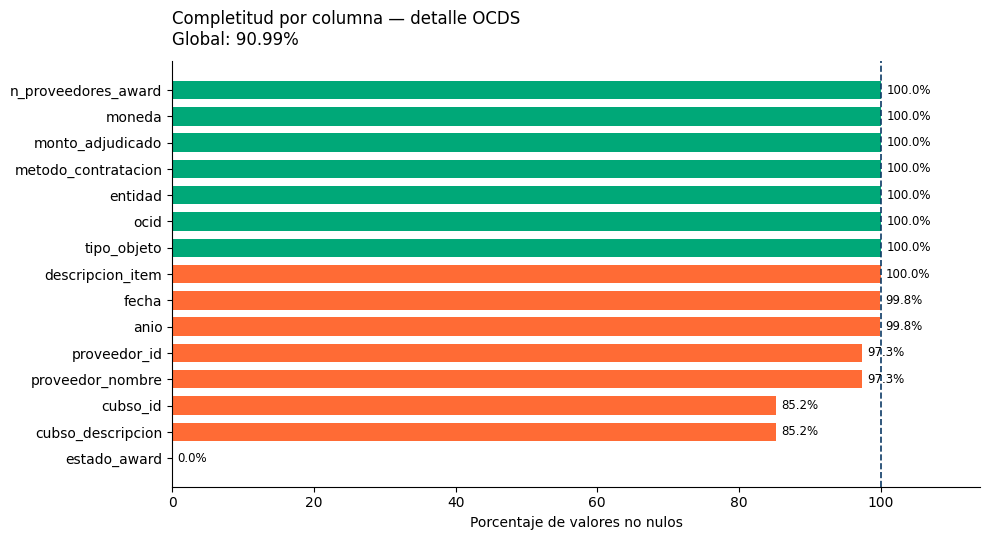

,Completitud %,Valores faltantes
Columna,,
estado_award,0.00,"228,012"
cubso_descripcion,85.23,"33,677"
cubso_id,85.24,"33,655"
proveedor_nombre,97.31,"6,134"
proveedor_id,97.34,"6,065"
fecha,99.84,365
anio,99.84,365
descripcion_item,99.97,68


In [7]:
comp = pd.Series(perfil_ocds["completitud"]["por_columna_pct"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 5.5))
colores = np.where(comp.values < 100, NARANJA, VERDE)
barras = ax.barh(comp.index, comp.values, color=colores, height=0.7)
ax.bar_label(barras, fmt="%.1f%%", padding=4, fontsize=8.5)
ax.set_xlim(0, 114)
ax.set_xlabel("Porcentaje de valores no nulos")
ax.set_title(f"Completitud por columna — detalle OCDS\n"
             f"Global: {perfil_ocds['completitud']['global_pct']}%",
             fontsize=12, loc="left", pad=12)
ax.axvline(100, color=AZUL, linestyle="--", linewidth=1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

incompletas = perfil_ocds["completitud"]["columnas_incompletas"]
if incompletas:
    df_inc = pd.Series(incompletas).sort_values().to_frame("Completitud %")
    df_inc["Valores faltantes"] = (
        (1 - df_inc["Completitud %"] / 100) * len(ocds)).round(0).astype(int)
    df_inc.index.name = "Columna"
    display(tabla(df_inc, "Columnas con datos faltantes", decimales=2))

**Qué muestra.** Las columnas en naranja tienen huecos. La que más importa es `cubso_descripcion`: cada fila sin categoría es un monto adjudicado que existe como registro pero no entra en ninguna categoría del radar. No se pierde el dato, se pierde su contribución a la demanda.

Por eso esa condición se mide además como regla de consistencia (`monto_sin_categoria`) más abajo: la completitud dice cuántos faltan, la consistencia dice qué consecuencia tiene.

Las columnas del bloque de adjudicación vienen vacías en los procesos publicados sin adjudicar todavía. Es información legítima, no un defecto de la fuente.

## 2.2 Unicidad

Proporción de registros no duplicados **según la clave de negocio**, no según la fila completa.

La distinción importa. Dos filas idénticas en todas sus columnas son un problema evidente y fácil de detectar. Dos filas con el mismo identificador pero datos distintos son un problema peor, y solo aparece si se mide contra la clave.

In [8]:
uni = perfil_ocds["unicidad"]
df_uni = pd.DataFrame([
    {"Concepto": "Clave de unicidad", "Valor": " + ".join(uni["clave"])},
    {"Concepto": "Registros totales", "Valor": f"{uni['registros']:,}"},
    {"Concepto": "Registros duplicados", "Valor": f"{uni['duplicados']:,}"},
    {"Concepto": "Unicidad", "Valor": f"{uni['unicidad_pct']}%"},
]).set_index("Concepto")

tabla(df_uni, "Unicidad del detalle OCDS", ancho_col="280px")

,Valor
Concepto,
Clave de unicidad,ocid + cubso_id + proveedor_id
Registros totales,"228,012"
Registros duplicados,"7,113"
Unicidad,96.88%


**Qué muestra.** Los duplicados que aparecen no son necesariamente errores. Un mismo proceso puede adjudicar la misma categoría al mismo proveedor en varios ítems distintos (por ejemplo, tres presentaciones de un mismo medicamento), y eso produce filas con clave repetida que son legítimas.

Lo que la métrica aporta es la magnitud: si ese porcentaje se disparara de una corrida a otra, indicaría un cambio en cómo la fuente publica los ítems, no un aumento del gasto público.

## 2.3 Validez

Proporción de valores que pertenecen a los dominios permitidos. Cada comprobación es una máscara booleana sobre la columna completa.

Los nulos quedan fuera del denominador a propósito: un valor ausente es un problema de completitud, no de validez, y mezclarlos contamina las dos métricas.

In [9]:
validez_tabla = pd.DataFrame(perfil_ocds["validez"]).T
validez_tabla = validez_tabla[["evaluados", "fuera_de_dominio", "validez_pct"]]
validez_tabla.columns = ["Valores evaluados", "Fuera de dominio", "Validez %"]
validez_tabla.index.name = "Columna"

display(tabla(validez_tabla, "Validez por dominio — detalle OCDS"))

# Los dominios están declarados en calidad.py, no escondidos en el código.
dominios = pd.DataFrame([
    {"Columna": "moneda",
     "Dominio permitido": ", ".join(calidad.MONEDAS_VALIDAS)},
    {"Columna": "estado_award",
     "Dominio permitido": ", ".join(calidad.ESTADOS_AWARD_VALIDOS)},
    {"Columna": "tipo_objeto",
     "Dominio permitido": ", ".join(calidad.TIPOS_OBJETO_VALIDOS)},
    {"Columna": "proveedor_id",
     "Dominio permitido": "sufijo numérico de 11 dígitos (RUC)"},
]).set_index("Columna")
tabla(dominios, "Dominios declarados", ancho_col="400px")

,Valores evaluados,Fuera de dominio,Validez %
Columna,,,
moneda,"228,008",107,99.95
tipo_objeto,"228,012",0,100.00
proveedor_id,"221,950","50,141",77.41


,Dominio permitido
Columna,
moneda,"PEN, USD, EUR"
estado_award,"active, cancelled, unsuccessful, pending"
tipo_objeto,"goods, services, works"
proveedor_id,sufijo numérico de 11 dígitos (RUC)


**Qué muestra.** La validez de `proveedor_id` es la más baja, y ese hallazgo tiene consecuencias directas sobre el proyecto: los identificadores sin RUC de once dígitos no se pueden consultar contra el registro del OECE, así que quedan fuera de la capa de habilitados.

Puede tratarse de consorcios, de proveedores extranjeros o de un formato distinto que convendría contemplar. Sea cual sea la explicación, la métrica lo convierte en un número declarado en lugar de una sorpresa que aparece al final de una descarga larga.

Tener los dominios escritos en `calidad.py` cumple otra función: si mañana el OECE agrega un estado de adjudicación nuevo, la métrica lo marca como fuera de dominio y el equipo se entera antes de que el tablero muestre una categoría vacía.

## 2.4 Consistencia

Coherencia lógica entre columnas del mismo registro. Son las incoherencias que ninguna comprobación columna por columna puede detectar, porque cada regla cruza al menos dos campos.

In [10]:
cons = pd.DataFrame(perfil_ocds["consistencia"]).T
cols = [c for c in ["registros", "pct", "impacto"] if c in cons.columns]
cons = cons[cols]
cons.columns = ["Registros afectados", "% del total", "Impacto"][:len(cols)]
cons.index = [i.replace("_", " ").capitalize() for i in cons.index]
cons.index.name = "Regla de consistencia"

tabla(cons, "Consistencia — detalle OCDS", ancho_col="300px")

,Registros afectados,% del total,Impacto
Regla de consistencia,,,
Monto sin categoria,"33,677",14.77,el monto no entra en ninguna categoría del radar
Adjudicacion activa sin proveedor,0.00,—,—
Anio no coincide con fecha,0.00,0.00,—


**Qué muestra.** La regla `Monto sin categoria` es la de mayor impacto. Cada uno de esos registros es dinero adjudicado que el radar no puede atribuir a ninguna categoría, así que la demanda total del catálogo queda por debajo del gasto real.

Es una limitación de la fuente, no del cálculo, y va declarada como tal en la ficha metodológica: el radar mide la demanda **clasificada**, que es un subconjunto de la demanda total.

Las otras dos reglas verifican que la ingesta no haya introducido incoherencias propias: que ninguna adjudicación activa se haya quedado sin proveedor y que el año derivado coincida con la fecha de la que se derivó.

## 2.5 Exactitud

Plausibilidad de los valores numéricos, con dos lecturas que dicen cosas distintas y que conviene no confundir.

La **cota fija** detecta errores de unidad, y es binaria: un contrato de S/ 0.03 o de noventa mil millones está mal cargado, no existe.

El **rango intercuartílico** detecta valores extremos relativos a la propia distribución. En compras públicas casi nunca son errores, porque los megaproyectos existen de verdad, pero conviene tenerlos contados antes de escalar.

In [11]:
exa = pd.DataFrame(perfil_ocds["exactitud"]).T
exa = exa[["evaluados", "fuera_de_cota", "exactitud_pct",
           "atipicos_iqr", "atipicos_iqr_pct", "limite_superior_iqr"]]
exa.columns = ["Evaluados", "Fuera de cota", "Exactitud %",
               "Atípicos IQR", "Atípicos %", "Límite superior IQR (S/)"]
exa.index.name = "Columna"

tabla(exa, "Exactitud — detalle OCDS")

,Evaluados,Fuera de cota,Exactitud %,Atípicos IQR,Atípicos %,Límite superior IQR (S/)
Columna,,,,,,
monto_adjudicado,"228,012.00",6.00,100.00,"33,161.00",14.54,"949,092.61"


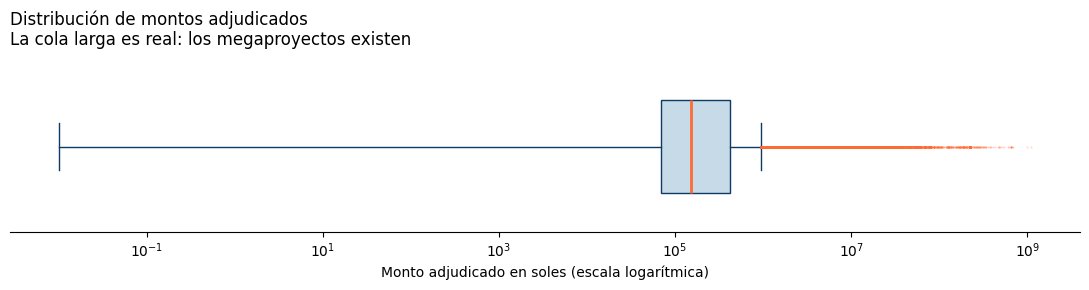

,Registros,% del total,Interpretación
Criterio,,,
Atípicos por IQR,"33,161",14.5400,"Contratos grandes reales, no errores"
Fuera de cota fija,6,0.0026,Errores de unidad o de carga


In [12]:
serie = ocds["monto_adjudicado"].dropna()
q1, q3 = serie.quantile([0.25, 0.75])
limite = q3 + 1.5 * (q3 - q1)

fig, ax = plt.subplots(figsize=(11, 3))
ax.boxplot(serie, vert=False, widths=0.55, patch_artist=True,
           boxprops=dict(facecolor=AZUL_2 + "40", color=AZUL),
           medianprops=dict(color=NARANJA, linewidth=2),
           whiskerprops=dict(color=AZUL), capprops=dict(color=AZUL),
           flierprops=dict(marker=".", markersize=3, alpha=0.25,
                           markerfacecolor=NARANJA, markeredgecolor="none"))
ax.set_xscale("log")
ax.set_xlabel("Monto adjudicado en soles (escala logarítmica)")
ax.set_title("Distribución de montos adjudicados\n"
             "La cola larga es real: los megaproyectos existen",
             fontsize=12, loc="left", pad=12)
ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout(); plt.show()

fuera_cota = int((~serie.between(calidad.MONTO_MINIMO_PLAUSIBLE,
                                 calidad.MONTO_MAXIMO_PLAUSIBLE)).sum())
comparativa = pd.DataFrame([
    {"Criterio": "Atípicos por IQR", "Registros": int((serie > limite).sum()),
     "% del total": round(100 * (serie > limite).mean(), 2),
     "Interpretación": "Contratos grandes reales, no errores"},
    {"Criterio": "Fuera de cota fija", "Registros": fuera_cota,
     "% del total": round(100 * fuera_cota / len(serie), 4),
     "Interpretación": "Errores de unidad o de carga"},
]).set_index("Criterio")
tabla(comparativa, "Dos criterios, dos significados", decimales=4,
      ancho_col="290px")

**Qué muestra.** Los dos conteos no miden lo mismo, y confundirlos llevaría a borrar datos buenos.

Los montos por encima del IQR son obras viales, medicamentos, combustible. En compras públicas la cola larga es la naturaleza del fenómeno, y descartarla dejaría al radar sin las categorías que más presupuesto mueven.

Los montos fuera de la cota fija sí son errores de carga, y son poquísimos.

Esta distinción es exactamente la razón por la que en la sección 4 el índice se construye aplicando logaritmo antes de escalar, en lugar de recortar los extremos: la cola no se elimina, se comprime.

## 2.6 Actualidad

Antigüedad del dato más reciente. Es la métrica que más riesgo cubre en este proyecto y la que ningún esquema de validación puede detectar.

Un pipeline puede correr sin un solo error y estar publicando datos de hace un año porque la fuente dejó de replicarse. El OECE replica el OCDS mensualmente, así que un desfase de semanas es normal y uno de varios meses no lo es.

In [13]:
act = perfil_ocds["actualidad"]
df_act = pd.DataFrame([
    {"Concepto": "Fecha más antigua del dataset", "Valor": act["fecha_mas_antigua"]},
    {"Concepto": "Fecha más reciente del dataset", "Valor": act["fecha_mas_reciente"]},
    {"Concepto": "Desfase respecto de hoy", "Valor": f"{act['dias_de_desfase']} días"},
    {"Concepto": "Umbral de vigencia definido", "Valor": f"{act['umbral_dias']} días"},
    {"Concepto": "¿Se considera vigente?", "Valor": "SÍ" if act["vigente"] else "NO"},
]).set_index("Concepto")

tabla(df_act, "Actualidad del detalle OCDS", ancho_col="280px")

,Valor
Concepto,
Fecha más antigua del dataset,2024-01-02
Fecha más reciente del dataset,2025-12-31
Desfase respecto de hoy,210 días
Umbral de vigencia definido,120 días
¿Se considera vigente?,NO


**Qué muestra.** El desfase es la distancia entre hoy y la adjudicación más reciente del archivo. Un valor alto puede significar dos cosas: que la descarga masiva no se actualizó, o que el propio OECE demoró en publicar.

En cualquiera de los dos casos, el tablero estaría mostrando historia y no el estado presente. Por eso el proyecto complementa esta fuente con el monitor de convocatorias vigentes, que consulta la API en vivo y responde qué está abierto **hoy**.

---
# 3. Enriquecimiento interno

## Qué se va a hacer

Generar variables nuevas a partir de lo que ya está en el dataset, sin traer fuentes adicionales.

Antes del código va lo que el profesor pidió explícitamente: **cuáles son las reglas de negocio que se están planteando**. Cada variable derivada encierra una afirmación sobre el dominio, y esa afirmación tiene que poder discutirse por separado del código que la implementa.

Después vienen las tres técnicas:

1. **Variables derivadas** — cálculos sobre columnas de la misma fila.
2. **Agregaciones** — resúmenes por grupo que se reincorporan al dataset.
3. **Binning** — cortar variables continuas en bandas interpretables.

La segunda incluye la recuperación de información que se estaba desperdiciando: la columna `fecha` del OCDS se guardaba desde la ingesta pero la agregación por categoría la descartaba.

## 3.1 De las preguntas de negocio a las reglas de negocio

El proyecto declaró cinco preguntas de negocio que la Data App tiene que contestar. Las reglas de negocio no son una lista aparte: son las decisiones que hay que tomar para poder contestarlas, y cada variable derivada implementa una de ellas.

### Las cinco preguntas y qué hace falta para responderlas

| Pregunta declarada | Fuente | Qué hace falta construir |
|:---|:---|:---|
| **Q1.** ¿Qué categorías CUBSO concentran la mayor demanda histórica del Estado, en soles y en número de procesos? | OCDS/SEACE | Agregación por categoría: `demanda_soles`, `n_procesos` |
| **Q2.** ¿Qué categorías presentan alta demanda y una baja cantidad de proveedores únicos adjudicados? | OCDS: demanda × adjudicatarios | `densidad_proveedores`, `concentracion`, `espacio_mercado` |
| **Q3.** ¿Cómo varía la demanda por año, entidad contratante y rango de monto? | OCDS/SEACE | Agregaciones por año y entidad, más **binning** del monto |
| **Q4.** ¿Cuál es el monto promedio adjudicado por proceso en cada categoría y qué nivel de acceso representa para una MYPE? | Derivada | `ticket_promedio`, `ticket_uit`, `banda_ticket`, `accesibilidad` |
| **Q5.** ¿Qué cobertura tiene la identificación de proveedores adjudicados por categoría y qué registros requieren validación contra el padrón oficial? | OCDS + API OECE | Métricas de validez y cobertura del padrón |

Vale la pena señalar de dónde sale cada técnica del Tema 4, porque no se eligieron por cumplir el temario:

- El **binning** aparece porque Q3 pregunta literalmente por *rango de monto*, y un rango es una banda. Q4 pregunta por *nivel de acceso*, que es la misma discretización leída desde el lado del proveedor.
- El **escalado** aparece porque Q2 cruza dos magnitudes de escalas incomparables (soles contra conteo de proveedores) y hay que poder combinarlas.
- Las **métricas de calidad** aparecen porque Q5 es, literalmente, una pregunta de calidad de datos.

### Las reglas de negocio que se derivan

Cada regla es una decisión que hubo que tomar para contestar alguna de las cinco preguntas. Se agrupan por el origen de su fundamento, porque no todas son igual de discutibles.

#### Reglas con base normativa

Vienen de la Ley N.º 32069 y su reglamento. No son decisiones del equipo: si cambia la ley, cambian.

| # | Responde a | Regla de negocio | Expresión |
|:--|:--|:---|:---|
| **R1** | Q4 | El tamaño de un contrato se mide en UIT, no en soles | `ticket_uit = ticket_promedio / UIT` |
| **R2** | Q3, Q4 | Hasta 8 UIT la contratación es menor y tiene requisitos reducidos | Primer corte de `banda_ticket` |
| **R3** | Q5 | Un proveedor solo compite en categorías del capítulo RNP donde está habilitado | Cruce CUBSO → capítulo |

#### Reglas del dominio de compras públicas

Salen de cómo funciona el mercado, no de la ley. Son las más discutibles y las que conviene defender con datos.

| # | Responde a | Regla de negocio | Expresión |
|:--|:--|:---|:---|
| **R4** | Q1, Q2 | Hay oportunidad donde el Estado compra mucho y compiten pocos | `potencial = 0.55·demanda + 0.45·espacio` |
| **R5** | Q4 | Un contrato que la empresa no puede asumir no es una oportunidad, por grande que sea el mercado | `índice = potencial × accesibilidad` |
| **R6** | Q2, Q5 | La competencia son los ganadores que siguen habilitados, no los ganadores históricos | `competencia_vigente = OCDS ∩ RNP habilitados` |
| **R7** | Q3 | Una categoría es estacional si concentra más del 25 % de su monto anual en un solo mes **y** tiene al menos 6 meses activos | `es_estacional` |
| **R8** | Q1 | Una categoría es accionable hoy solo si tiene llamados abiertos | `accionable_hoy = convocatorias > 0` |
| **R9** | Q1, Q2 | Una compra que ocurrió una sola vez no es un mercado | `apto_para_ranking` (≥2 procesos y ≥20 UIT) |

#### Reglas de integridad

Definen qué datos son admisibles. Son las únicas que se comprueban automáticamente en cada corrida, en la sección 5.

| # | Responde a | Regla de negocio | Expresión |
|:--|:--|:---|:---|
| **R10** | Q2 | No puede haber más proveedores adjudicados que adjudicaciones | `adjudicados ≤ n_adjudicaciones` |
| **R11** | Q4 | El ticket promedio debe reconstruirse desde sus componentes | `ticket ≈ demanda / procesos` |
| **R12** | Q2 | Los que siguen habilitados son un subconjunto de los que ganaron | `competencia_vigente ≤ ganadores_historicos` |
| **R13** | Q2 | Un mercado desierto es el que tuvo ganadores y hoy no tiene ninguno | `mercado_desierto` coherente |
| **R14** | Q1 | El índice se publica en escala 0 a 100 | Rango del esquema |

In [14]:
reglas_negocio = pd.DataFrame([
    {"Código": "R1", "Responde": "Q4", "Familia": "Normativa",
     "Regla": "El tamaño del contrato se mide en UIT",
     "Dónde vive": "transformacion.enriquecer()"},
    {"Código": "R2", "Responde": "Q3, Q4", "Familia": "Normativa",
     "Regla": "Hasta 8 UIT es contratación menor",
     "Dónde vive": "config.BANDAS_TICKET_UIT"},
    {"Código": "R3", "Responde": "Q5", "Familia": "Normativa",
     "Regla": "Solo se compite donde hay habilitación por capítulo",
     "Dónde vive": "diccionario_cubso.py"},
    {"Código": "R4", "Responde": "Q1, Q2", "Familia": "Dominio",
     "Regla": "Oportunidad = mucha demanda y poca competencia",
     "Dónde vive": "config.PESOS_INDICE"},
    {"Código": "R5", "Responde": "Q4", "Familia": "Dominio",
     "Regla": "La accesibilidad multiplica, no suma",
     "Dónde vive": "config.FACTOR_ACCESIBILIDAD"},
    {"Código": "R6", "Responde": "Q2, Q5", "Familia": "Dominio",
     "Regla": "Competencia = ganadores que siguen habilitados",
     "Dónde vive": "consulta_proveedores.calcular_competencia_vigente()"},
    {"Código": "R7", "Responde": "Q3", "Familia": "Dominio",
     "Regla": "Estacional: 25 % en un mes y 6 meses activos",
     "Dónde vive": "transformacion.UMBRAL_MES_PICO"},
    {"Código": "R8", "Responde": "Q1", "Familia": "Dominio",
     "Regla": "Accionable solo con llamados abiertos",
     "Dónde vive": "diagnostico.construir_maestro()"},
    {"Código": "R9", "Responde": "Q1, Q2", "Familia": "Dominio",
     "Regla": "Una compra única no es un mercado",
     "Dónde vive": "config.MINIMO_PROCESOS_MERCADO"},
    {"Código": "R10", "Responde": "Q2", "Familia": "Integridad",
     "Regla": "Adjudicados ≤ adjudicaciones",
     "Dónde vive": "validacion.reglas_de_negocio()"},
    {"Código": "R11", "Responde": "Q4", "Familia": "Integridad",
     "Regla": "El ticket se reconstruye desde sus componentes",
     "Dónde vive": "validacion.reglas_de_negocio()"},
    {"Código": "R12", "Responde": "Q2", "Familia": "Integridad",
     "Regla": "Habilitados vigentes ≤ ganadores históricos",
     "Dónde vive": "validacion.reglas_de_negocio()"},
    {"Código": "R13", "Responde": "Q2", "Familia": "Integridad",
     "Regla": "La bandera de mercado desierto es coherente",
     "Dónde vive": "validacion.reglas_de_negocio()"},
    {"Código": "R14", "Responde": "Q1", "Familia": "Integridad",
     "Regla": "El índice vive en [0, 100]",
     "Dónde vive": "validacion.ESQUEMA_MAESTRO"},
]).set_index("Código")

tabla(reglas_negocio, "Las catorce reglas de negocio, la pregunta que responden "
                      "y dónde vive cada una", ancho_col="250px")

,Responde,Familia,Regla,Dónde vive
Código,,,,
R1,Q4,Normativa,El tamaño del contrato se mide en UIT,transformacion.enriquecer()
R2,"Q3, Q4",Normativa,Hasta 8 UIT es contratación menor,config.BANDAS_TICKET_UIT
R3,Q5,Normativa,Solo se compite donde hay habilitación por capítulo,diccionario_cubso.py
R4,"Q1, Q2",Dominio,Oportunidad = mucha demanda y poca competencia,config.PESOS_INDICE
R5,Q4,Dominio,"La accesibilidad multiplica, no suma",config.FACTOR_ACCESIBILIDAD
R6,"Q2, Q5",Dominio,Competencia = ganadores que siguen habilitados,consulta_proveedores.calcular_competencia_vigente()
R7,Q3,Dominio,Estacional: 25 % en un mes y 6 meses activos,transformacion.UMBRAL_MES_PICO
R8,Q1,Dominio,Accionable solo con llamados abiertos,diagnostico.construir_maestro()
R9,"Q1, Q2",Dominio,Una compra única no es un mercado,config.MINIMO_PROCESOS_MERCADO


**Qué muestra.** Cada regla tiene un lugar único en el código, y ese lugar es un parámetro con nombre, no un número suelto en medio de un cálculo.

Esa correspondencia es lo que permite discutir una regla sin discutir el código. Si alguien objeta que el factor de accesibilidad de la banda intermedia debería ser 0.50 en lugar de 0.35, se cambia una línea de `config.py` y todo el pipeline se recalcula, sin tocar la lógica.

Las reglas de integridad (R9 a R12) son las únicas que se comprueban automáticamente en cada corrida. Las otras ocho son decisiones de diseño: se sostienen con argumentos, no con validaciones.

## 3.2 Variables derivadas

Cinco variables, cada una implementando una de las reglas anteriores:

| Variable | Regla | Qué aporta |
|:---|:---|:---|
| `ticket_uit` | R1, R2 | El ticket promedio en múltiplos de UIT, que es la unidad de la normativa |
| `espacio_mercado` | R6 | El complemento logarítmico de la competencia vigente, para que la señal apunte en la misma dirección que la demanda |
| `origen_espacio` | R6 | Si la fila usó el cruce real contra el RNP o el indicador sustituto |
| `apto_para_ranking` | R9 | Si la categoría es un mercado recurrente o una compra aislada |
| `mes_pico`, `es_estacional` | R7 | El perfil temporal, que sale de la columna `fecha` del OCDS |

In [15]:
print(inspect.getsource(transformacion.enriquecer))

def enriquecer(maestro: pd.DataFrame, perfil_temporal: pd.DataFrame | None
               ) -> pd.DataFrame:
    """Agrega las variables derivadas al maestro.

    Todas salen de columnas que ya están en el dataset. No hay fuente nueva:
    eso es lo que distingue el enriquecimiento interno de una integración.
    """
    df = maestro.copy()

    # --- Variables derivadas de la propia fila -----------------------------
    # Ticket en UIT: la misma cifra que `ticket_promedio` pero en la unidad
    # que usa la normativa, así el usuario compara contra los umbrales legales
    # que ya conoce en lugar de traducir soles mentalmente.
    df["ticket_uit"] = (df["ticket_promedio"] / config.UIT_SOLES).round(2)

    # ESPACIO DE MERCADO — cuántos competidores quedan en carrera
    # ----------------------------------------------------------
    # Se construye sobre `competencia_vigente`: los adjudicatarios de la
    # categoría que siguen habilitados en el RNP. Es el cruce del OCDS con la
    

In [16]:
# La estacionalidad sale de la columna `fecha`, que hasta ahora no se usaba.
perfil_temporal = transformacion.estacionalidad_por_categoria(ocds)
enriquecido = transformacion.enriquecer(maestro_crudo, perfil_temporal)

nuevas = [c for c in enriquecido.columns if c not in maestro_crudo.columns]
df_nuevas = pd.DataFrame({
    "Variable": nuevas,
    "Tipo": [str(enriquecido[c].dtype) for c in nuevas],
    "No nulos": [int(enriquecido[c].notna().sum()) for c in nuevas],
    "Cobertura %": [round(100 * enriquecido[c].notna().mean(), 1) for c in nuevas],
}).set_index("Variable")

print(f"Variables originales: {maestro_crudo.shape[1]}   →   "
      f"tras enriquecer: {enriquecido.shape[1]}\n")
tabla(df_nuevas, "Variables creadas por enriquecimiento interno", decimales=1)

Variables originales: 19   →   tras enriquecer: 27



,Tipo,No nulos,Cobertura %
Variable,,,
ticket_uit,float64,"30,709",100.0
espacio_mercado,float64,"30,709",100.0
origen_espacio,str,"30,709",100.0
apto_para_ranking,bool,"30,709",100.0
mes_pico,Int8,"30,700",100.0
concentracion_mes,float64,"30,700",100.0
meses_activos,float64,"30,700",100.0
es_estacional,object,"30,709",100.0


**Qué muestra.** Las variables nuevas tienen cobertura casi completa. `espacio_mercado` cubre 30 701 de 30 709 categorías, y las ocho que faltan son las que existen en la demanda pero no tienen ninguna adjudicación con proveedor identificado, así que no llegan al dataset de densidad.

`origen_espacio` deja el conteo a la vista: cuántas filas se apoyan en el cruce real contra el RNP y cuántas caen al sucedáneo de concentración. Sin esa columna no habría forma de saber qué parte del resultado descansa en una aproximación.

In [17]:
muestra = (enriquecido[["cubso_descripcion", "ticket_uit", "ganadores_historicos",
                        "competencia_vigente", "espacio_mercado",
                        "origen_espacio", "apto_para_ranking"]]
           .head(6).set_index("cubso_descripcion"))
muestra.index.name = "Categoría CUBSO"
muestra.columns = ["Ticket (UIT)", "Ganaron alguna vez", "Siguen habilitados",
                   "Espacio de mercado", "Origen del espacio", "Apta para ranking"]

display(tabla(muestra, "Variables derivadas — muestra", decimales=4,
              ancho_col="160px"))

origen = enriquecido["origen_espacio"].value_counts()
df_origen = origen.to_frame("Categorías")
df_origen["% del catálogo"] = (100 * origen / len(enriquecido)).round(2)
df_origen.index.name = "Origen del espacio de mercado"

tabla(df_origen, "De dónde sale el espacio de mercado en cada fila",
      decimales=2, ancho_col="230px")

,Ticket (UIT),Ganaron alguna vez,Siguen habilitados,Espacio de mercado,Origen del espacio,Apta para ranking
Categoría CUBSO,,,,,,
SERVICIO DE SEGURIDAD Y VIGILANCIA,815.6900,426.0000,333.0000,0.1925,competencia_vigente,True
SERVICIO DE MANTENIMIENTO PERIODICO DE CARRETERAS,"3,446.9500",104.0000,93.0000,0.3687,competencia_vigente,True
CONSTRUCCION DE CARRETERA,"3,494.3600",84.0000,74.0000,0.4001,competencia_vigente,True
CONSTRUCCION DE INFRAESTRUCTURA DE SALUD,"4,945.9600",47.0000,43.0000,0.4742,competencia_vigente,True
AMPLIACION DE INFRAESTRUCTURA DE CENTROS EDUCATIVOS,"1,381.7300",116.0000,101.0000,0.3573,competencia_vigente,True
CONSTRUCCION DE CENTROS EDUCATIVOS,985.3700,168.0000,150.0000,0.3028,competencia_vigente,True


,Categorías,% del catálogo
Origen del espacio de mercado,,
competencia_vigente,"28,279",92.09
concentracion,"2,430",7.91


**Qué muestra.** `ticket_uit` traduce soles a la unidad que usa la normativa. Un proveedor que ya sabe que hasta 8 UIT la contratación es menor lee la tabla sin traducir mentalmente.

Las dos columnas de competencia se muestran juntas a propósito. `ganadores_historicos` sale del OCDS y `competencia_vigente` del cruce contra el RNP: su diferencia es cuánta rotación tuvo el rubro. Una categoría con tres ganadores de los que ninguno sigue habilitado no es lo mismo que una con tres ganadores todos vigentes, y un solo número no distingue esos dos casos.

`espacio_mercado` es la versión de esa cuenta que entra al índice: logaritmo para comprimir la cola (la competencia va de 0 a 1 334 empresas) e inversión para que más espacio dé más puntaje.

### Un indicador que se descartó al medirlo

La primera versión del proyecto resumía el contraste entre las dos fuentes en un cociente de saturación:

$$\text{saturación} = \frac{\text{adjudicados de la categoría CUBSO}}{\text{habilitados del capítulo RNP}}$$

La idea era razonable sobre el papel: si casi todos los habilitados del rubro ya ganaron, el mercado está copado. El problema aparece al mirar los números, no al leer la fórmula.

El numerador se cuenta con grano fino, proveedores que ganaron en esa categoría específica. El denominador se cuenta con grano grueso, porque un capítulo del RNP agrupa miles de categorías. Son cuatro capítulos (BIENES, SERVICIOS, EJECUTOR_DE_OBRAS, CONSULTOR_DE_OBRAS) repartiendo su conteo de habilitados entre 30 701 categorías.

Ahora que la capa está descargada completa se puede medir la asimetría en lugar de anticiparla. Las dos columnas que componían el cociente siguen publicadas, así que se reconstruye acá para dejar la medición a la vista.

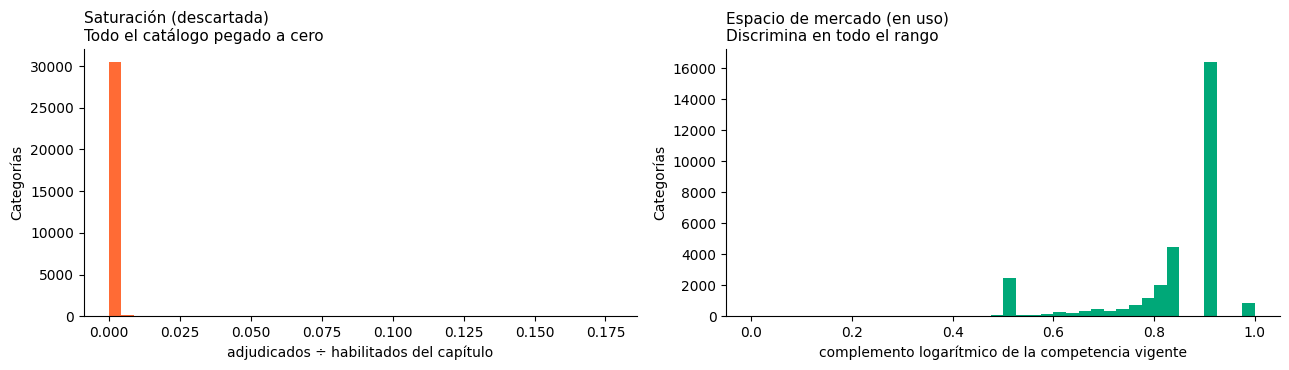

,Saturación (descartada),Espacio de mercado (en uso)
Media,0.0003,0.8284
Desv. estándar,0.0032,0.1293
Mínimo,0.0000,0.0000
Percentil 25,0.0000,0.8074
Mediana,0.0000,0.9037
Percentil 75,0.0001,0.9037
Máximo,0.1774,1.0000


,Valores distintos,Categorías en el valor modal
Variable,,
Saturación (descartada),195,61.5%
Espacio de mercado (en uso),165,53.4%


In [18]:
# La saturación ya no se publica como columna. Se reconstruye desde las dos
# columnas que la componían, que sí siguen en el dataset, para poder medir por
# qué se descartó en lugar de afirmarlo.
sat = (densidad["adjudicados"] / densidad["habilitados_capitulo"]).dropna()
esp = enriquecido["espacio_mercado"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(sat, bins=40, color=NARANJA, edgecolor="none")
axes[0].set_title("Saturación (descartada)\nTodo el catálogo pegado a cero",
                  fontsize=11, loc="left")
axes[0].set_xlabel("adjudicados ÷ habilitados del capítulo")
axes[1].hist(esp, bins=40, color=VERDE, edgecolor="none")
axes[1].set_title("Espacio de mercado (en uso)\nDiscrimina en todo el rango",
                  fontsize=11, loc="left")
axes[1].set_xlabel("complemento logarítmico de la competencia vigente")
for ax in axes:
    ax.set_ylabel("Categorías")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

comp_sat = pd.DataFrame({
    "Saturación (descartada)": sat.describe(),
    "Espacio de mercado (en uso)": esp.describe(),
}).drop("count")
comp_sat.index = ["Media", "Desv. estándar", "Mínimo", "Percentil 25",
                  "Mediana", "Percentil 75", "Máximo"]
display(tabla(comp_sat, "Distribución comparada", decimales=4,
              ancho_col="210px"))

# El argumento decisivo: cuántos valores distintos toma cada variable.
resolucion = pd.DataFrame([
    {"Variable": "Saturación (descartada)",
     "Valores distintos": f"{sat.round(4).nunique():,}",
     "Categorías en el valor modal":
        f"{sat.round(4).value_counts().iloc[0] / len(sat):.1%}"},
    {"Variable": "Espacio de mercado (en uso)",
     "Valores distintos": f"{esp.round(4).nunique():,}",
     "Categorías en el valor modal":
        f"{esp.round(4).value_counts().iloc[0] / len(esp):.1%}"},
]).set_index("Variable")

tabla(resolucion, "Cuánto puede ordenar cada variable", ancho_col="230px")

**Qué muestra.** La saturación tiene mediana 0.0000 y máximo 0.1774. Ninguna categoría del catálogo llega siquiera a la quinta parte de su capítulo, así que un índice construido sobre esta columna valdría casi lo mismo en todas las filas y dejaría de ordenar. La tabla de resolución lo dice sin ambigüedad: el valor modal de la saturación se repite en más de la mitad del catálogo.

Arreglarlo de raíz pediría contar habilitados por categoría CUBSO, y el RNP no publica esa desagregación porque la habilitación se otorga por capítulo. No es un defecto del pipeline: es una asimetría entre lo que la pregunta necesita y lo que la fuente entrega.

La salida fue cambiar la pregunta por una que la fuente sí puede contestar con grano homogéneo. En lugar de comparar los ganadores de la categoría contra los habilitados de todo el capítulo, se comparan los ganadores de la categoría **contra su propio estado de habilitación**. Eso es `competencia_vigente`, y su grano es el mismo en numerador y denominador porque son las mismas empresas.

Las dos columnas que componían el cociente (`adjudicados` y `habilitados_capitulo`) siguen en el dataset. La segunda se muestra en el tablero como contexto del sector, que es para lo que sirve: solo toma cuatro valores.

### Los empates que quedan son reales

El espacio de mercado también tiene valores repetidos, y conviene mirarlos antes de que alguien más lo haga. La diferencia con el caso anterior es de naturaleza: acá el empate no lo fabrica el cálculo.

In [19]:
# Miles de categorías comparten el mismo valor de espacio de mercado. La
# pregunta es si eso lo produce el redondeo del pipeline o si son categorías
# genuinamente equivalentes en la variable que se está midiendo.
comp = enriquecido["competencia_vigente"]
esp = enriquecido["espacio_mercado"]

modal = esp.round(4).value_counts().index[0]
en_modal = esp.round(4) == modal

df_empate = pd.DataFrame([
    {"Concepto": "Valor de espacio de mercado más repetido",
     "Valor": f"{modal:.4f}"},
    {"Concepto": "Categorías que lo comparten",
     "Valor": f"{int(en_modal.sum()):,} de {len(esp):,} "
              f"({en_modal.mean():.1%})"},
    {"Concepto": "Competidores vigentes de esas categorías",
     "Valor": f"{comp[en_modal].min():.0f} a {comp[en_modal].max():.0f}"},
    {"Concepto": "Valores distintos de competencia vigente en todo el catálogo",
     "Valor": f"{int(comp.nunique()):,}"},
    {"Concepto": "Competencia vigente: mínimo y máximo",
     "Valor": f"{comp.min():.0f} a {comp.max():.0f}"},
    {"Concepto": "Empate sin redondear a 4 decimales",
     "Valor": f"{(esp == esp.value_counts().index[0]).mean():.1%}"},
]).set_index("Concepto")

tabla(df_empate, "Los empates del espacio de mercado", ancho_col="300px")

,Valor
Concepto,
Valor de espacio de mercado más repetido,0.9037
Categorías que lo comparten,"16,387 de 30,709 (53.4%)"
Competidores vigentes de esas categorías,1 a 1
Valores distintos de competencia vigente en todo el catálogo,143
Competencia vigente: mínimo y máximo,0 a 1334
Empate sin redondear a 4 decimales,53.4%


**Qué muestra.** Las categorías que comparten el valor modal tienen todas **exactamente el mismo número de competidores vigentes**. No es un artefacto del redondeo: quitarlo no cambia la proporción, porque la variable de base es un conteo entero. Dos categorías con un solo competidor habilitado tienen el mismo espacio de mercado, y eso es correcto: la variable mide lo que dice medir.

La diferencia con la saturación es exactamente esta. Ahí el empate venía de dividir por un denominador que no distinguía categorías, y valores realmente distintos colapsaban en el mismo número. Acá el empate significa igualdad real en la dimensión medida.

Dentro de un mismo nivel de competencia el orden lo aporta la demanda, que es continua. Por eso el índice combina las dos señales con pesos declarados en lugar de apoyarse en una sola: cada una resuelve lo que la otra no distingue.

## 3.3 Agregaciones

Las agregaciones no son un paso posterior en este proyecto: son la forma en que se construyen los datasets. La ingesta agrupa el detalle por categoría CUBSO para obtener demanda y número de procesos; el módulo de proveedores agrupa por categoría para contar adjudicatarios únicos y por capítulo para contar habilitados.

La celda siguiente reproduce esa agregación sobre el detalle, ampliada con métricas adicionales, para mostrar el cambio de grano.

In [20]:
validos = ocds.dropna(subset=["cubso_descripcion", "monto_adjudicado"])

agregado = (validos.groupby("cubso_descripcion", as_index=False, observed=True)
            .agg(demanda_soles=("monto_adjudicado", "sum"),
                 n_procesos=("ocid", "nunique"),
                 proveedores_distintos=("proveedor_id", "nunique"),
                 entidades_distintas=("entidad", "nunique"),
                 monto_maximo=("monto_adjudicado", "max"))
            .sort_values("demanda_soles", ascending=False))

print(f"Cambio de grano: {len(validos):,} filas de detalle "
      f"→ {len(agregado):,} categorías\n")

top = agregado.head(8).set_index("cubso_descripcion")
top.index.name = "Categoría CUBSO"
top.columns = ["Demanda (S/)", "Procesos", "Proveedores distintos",
               "Entidades compradoras", "Monto máximo (S/)"]
barra_color(top, "Demanda (S/)",
            "Categorías con mayor demanda del Estado", decimales=0)

Cambio de grano: 194,335 filas de detalle → 30,709 categorías



,Demanda (S/),Procesos,Proveedores distintos,Entidades compradoras,Monto máximo (S/)
Categoría CUBSO,,,,,
SERVICIO DE SEGURIDAD Y VIGILANCIA,"8,156,077,002","1,818",624,422,"222,915,134"
SERVICIO DE MANTENIMIENTO PERIODICO DE CARRETERAS,"7,621,208,619",402,405,77,"356,253,522"
CONSTRUCCION DE CARRETERA,"7,437,744,345",387,391,226,"684,934,000"
CONSTRUCCION DE INFRAESTRUCTURA DE SALUD,"5,930,200,928",218,220,150,"1,111,909,484"
AMPLIACION DE INFRAESTRUCTURA DE CENTROS EDUCATIVOS,"4,506,507,834",593,590,298,"248,634,951"
CONSTRUCCION DE CENTROS EDUCATIVOS,"4,400,665,716",812,788,378,"187,075,509"
MEJORAMIENTO DE PISTAS Y VEREDAS,"4,287,514,763",856,803,399,"277,863,786"
CONSTRUCCION DE CALLES CON PAVIMENTO,"4,169,506,999","1,214","1,130",413,"220,393,739"


**Qué muestra.** La agregación es una sola operación `groupby` sobre toda la tabla, sin recorrer categoría por categoría. Con cientos de miles de filas esa diferencia es la que separa un cálculo instantáneo de uno que tarda minutos.

Las columnas de proveedores y entidades distintas se agregan con `nunique`, que es lo que permite después medir competencia: no basta con saber cuánto se compró, hay que saber entre cuántos se repartió.

### Q3: la demanda por año y por entidad contratante

Q3 pregunta por tres dimensiones: año, entidad contratante y rango de monto. La tercera se resuelve con binning más abajo; las dos primeras son agregaciones directas y van acá.

In [21]:
por_anio = (validos.groupby("anio", observed=True)
            .agg(demanda_soles=("monto_adjudicado", "sum"),
                 adjudicaciones=("ocid", "size"),
                 categorias=("cubso_descripcion", "nunique"),
                 ticket_medio=("monto_adjudicado", "mean")))
por_anio.index.name = "Año"
por_anio.columns = ["Demanda (S/)", "Adjudicaciones", "Categorías distintas",
                    "Ticket medio (S/)"]

display(tabla(por_anio, "Q3 — Variación de la demanda por año", decimales=0))

if len(por_anio) > 1:
    variacion = (por_anio["Demanda (S/)"].iloc[-1]
                 / por_anio["Demanda (S/)"].iloc[0] - 1)
    print(f"Variación entre el primer y el último año del período: {variacion:+.1%}")

,Demanda (S/),Adjudicaciones,Categorías distintas,Ticket medio (S/)
Año,,,,
2024,"97,388,458,206","89,685","19,994","1,085,895"
2025,"205,294,535,375","104,321","20,481","1,967,912"


Variación entre el primer y el último año del período: +110.8%


**Qué muestra.** La comparación entre años tiene una trampa que conviene declarar: el año más reciente puede aparecer con menos demanda simplemente porque el OECE todavía no terminó de publicar sus adjudicaciones. La caída no siempre es una caída del gasto; a veces es el rezago de publicación.

Es el mismo fenómeno que la métrica de actualidad mide desde otro ángulo, y la razón por la que el proyecto no interpreta tendencias interanuales sin mirar antes el desfase.

In [22]:
por_entidad = (validos.groupby("entidad", observed=True)
               .agg(demanda_soles=("monto_adjudicado", "sum"),
                    adjudicaciones=("ocid", "size"),
                    categorias=("cubso_descripcion", "nunique"),
                    ticket_medio=("monto_adjudicado", "mean"))
               .sort_values("demanda_soles", ascending=False))
por_entidad["participacion"] = (
    100 * por_entidad["demanda_soles"] / por_entidad["demanda_soles"].sum())

vista_ent = por_entidad.head(10).copy()
vista_ent.index.name = "Entidad contratante"
vista_ent.columns = ["Demanda (S/)", "Adjudicaciones", "Categorías distintas",
                     "Ticket medio (S/)", "Participación %"]

barra_color(vista_ent, "Demanda (S/)",
            "Q3 — Entidades que más compran", decimales=0)

,Demanda (S/),Adjudicaciones,Categorías distintas,Ticket medio (S/),Participación %
Entidad contratante,,,,,
CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,"85,538,542,714","3,899","1,188","21,938,585",28
SEGURO SOCIAL DE SALUD,"18,327,244,293","7,254","3,598","2,526,502",6
MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE NACIONAL (PROVIAS NACIONAL),"15,552,349,624","1,206",241,"12,895,812",5
PETROLEOS DEL PERU S.A.,"4,998,469,899","3,450","1,787","1,448,832",2
SERVICIO DE AGUA POTABLE Y ALCANTARILLADO DE LIMA - SEDAPAL,"4,487,519,577","1,047",598,"4,286,074",1
MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE DESCENTRALIZADO - PROVIAS DESCENTRALIZADO,"4,019,378,658",507,149,"7,927,769",1
GOBIERNO REGIONAL DE JUNIN SEDE CENTRAL,"3,986,870,283","1,012",403,"3,939,595",1
PROGRAMA NACIONAL DE SANEAMIENTO URBANO,"3,949,411,252",409,195,"9,656,262",1
FONDO INTANGIBLE SOLIDARIO DE SALUD,"3,333,582,702",318,18,"10,482,964",1


**Qué muestra.** La concentración por entidad es útil para el usuario del radar: si una categoría la compra casi exclusivamente una entidad, prepararse para competir ahí significa entender los pliegos de esa entidad en particular, no del Estado en general.

La columna de categorías distintas distingue dos perfiles de comprador. Una entidad con mucha demanda repartida en pocas categorías es un comprador especializado; una con demanda repartida en muchas es un comprador general, y ahí es más probable que aparezcan las categorías chicas y accesibles.

## 3.4 Agregación temporal: la variable que estaba desperdiciada

La ingesta guardaba la fecha de cada adjudicación, pero la agregación por categoría la descartaba. Esta agregación la recupera y produce, por categoría: el mes pico, qué proporción del monto anual cae en ese mes, cuántos meses tuvo actividad y si la categoría es estacional.

Es la variable que responde **cuándo** conviene prepararse, no solo dónde competir.

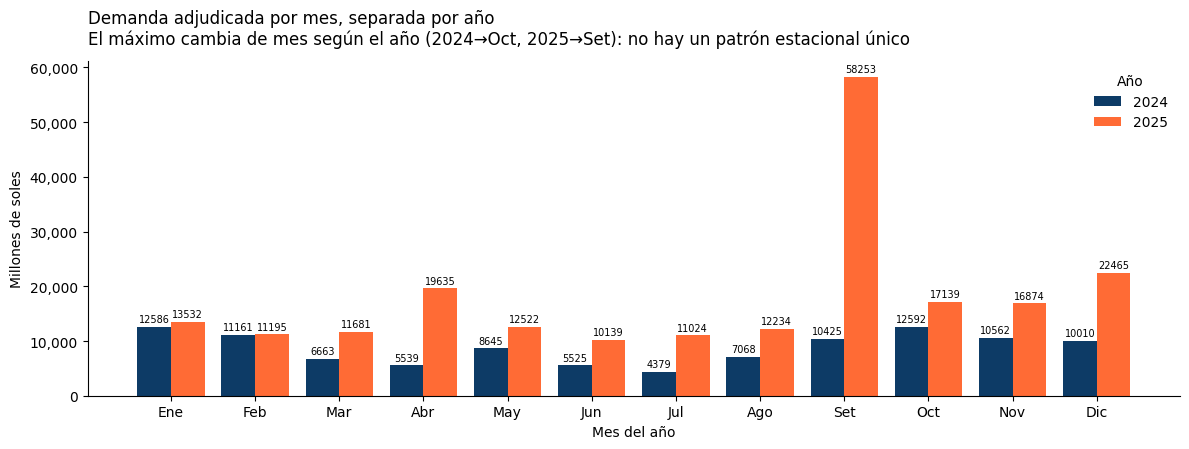

,Valor
Concepto,
Mes de mayor demanda (2024),"Oct — 12,592 MM (12.0% del año)"
Procesos en ese mes (2024),"13,338 adjudicaciones · ticket mediano 1.0× la mediana general"
Participación del último trimestre (2024),31.5%
Mes de mayor demanda (2025),"Set — 58,253 MM (26.9% del año)"
Procesos en ese mes (2025),"11,381 adjudicaciones · ticket mediano 1.1× la mediana general"
Participación del último trimestre (2025),26.1%
¿El pico se repite entre años?,"No, depende del año"
Participación si el reparto fuera plano,25.0% por trimestre


In [23]:
# --- Demanda adjudicada por mes, desagregada por año -------------------------
base = (ocds.dropna(subset=["fecha", "monto_adjudicado"])
        .assign(anio=lambda d: d["fecha"].dt.year.astype(int),
                mes=lambda d: d["fecha"].dt.month.astype(int)))

meses = range(1, 13)
gasto_am = (base.pivot_table(index="mes", columns="anio",
                             values="monto_adjudicado", aggfunc="sum")
            .reindex(meses).fillna(0) / 1e6)
conteo_am = (base.pivot_table(index="mes", columns="anio",
                              values="monto_adjudicado", aggfunc="count")
             .reindex(meses).fillna(0))
mediana_am = (base.pivot_table(index="mes", columns="anio",
                               values="monto_adjudicado", aggfunc="median")
              .reindex(meses))

anios = [int(a) for a in gasto_am.columns]
paleta = [AZUL, NARANJA, "#4E7A51", "#7A4E6E"][:len(anios)]

x = np.arange(12)
ancho = 0.8 / len(anios)

# ¿El mes máximo es el mismo todos los años? De eso depende la lectura.
picos = gasto_am.idxmax()
coincide = picos.nunique() == 1
if coincide:
    m_pico = int(picos.iloc[0])
    subtitulo = (f"El máximo cae en {NOMBRE_MES[m_pico - 1]} en todos los años: "
                 f"el patrón se repite y es atribuible a estacionalidad")
else:
    detalle = ", ".join(f"{a}→{NOMBRE_MES[int(picos[a]) - 1]}" for a in anios)
    subtitulo = (f"El máximo cambia de mes según el año ({detalle}): "
                 f"no hay un patrón estacional único")

fig, ax = plt.subplots(figsize=(12, 4.6))
for i, a in enumerate(anios):
    barras = ax.bar(x + i * ancho - 0.4 + ancho / 2, gasto_am[a].values,
                    width=ancho, label=str(a), color=paleta[i])
    ax.bar_label(barras, fmt="%.0f", padding=2, fontsize=7)

ax.set_xticks(x, [NOMBRE_MES[m - 1] for m in meses])
ax.set_xlabel("Mes del año")
ax.set_ylabel("Millones de soles")
ax.set_title("Demanda adjudicada por mes, separada por año\n" + subtitulo,
             fontsize=12, loc="left", pad=12)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(title="Año", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# --- Lectura numérica --------------------------------------------------------
mediana_global = base["monto_adjudicado"].median()
filas = []
for a in anios:
    col = gasto_am[a]
    m = int(col.idxmax())
    q4 = col.loc[[10, 11, 12]].sum() / col.sum()
    filas.append({
        "Concepto": f"Mes de mayor demanda ({a})",
        "Valor": f"{NOMBRE_MES[m - 1]} — {col.max():,.0f} MM "
                 f"({col.max() / col.sum():.1%} del año)"})
    filas.append({
        "Concepto": f"Procesos en ese mes ({a})",
        "Valor": f"{conteo_am.loc[m, a]:,.0f} adjudicaciones · "
                 f"ticket mediano {mediana_am.loc[m, a] / mediana_global:.1f}× "
                 f"la mediana general"})
    filas.append({"Concepto": f"Participación del último trimestre ({a})",
                  "Valor": f"{q4:.1%}"})

filas.append({"Concepto": "¿El pico se repite entre años?",
              "Valor": "Sí, es estacional" if coincide
                       else "No, depende del año"})
filas.append({"Concepto": "Participación si el reparto fuera plano",
              "Valor": "25.0% por trimestre"})

tabla(pd.DataFrame(filas).set_index("Concepto"),
      "Estacionalidad del gasto público, verificada por año", ancho_col="330px")

**Qué muestra**. El gráfico separa los años en vez de acumularlos: acumular escondía si el patrón se repite o si es un evento de un solo año.

El cierre presupuestal existe pero es moderado y desigual: el último trimestre pesa 31.5% en 2024 y 26.1% en 2025, frente al 25% de un reparto plano. Con dos ejercicios no alcanza para postularlo como regla estable.

Setiembre de 2025 concentra el 26.9% del año, pero el exceso está íntegramente en el percentil 99 de los montos: la mediana del mes es prácticamente igual a la de agosto (ratio 1.13) mientras el p99 es catorce veces mayor. Son contratos de gran envergadura, del tramo que el radar excluye con el filtro de banda de ticket. Ese pico no representa demanda accesible para una MYPE.

Por eso la lectura accionable de la estacionalidad no está en el monto adjudicado sino en el número de convocatorias por mes, que es lo que un proveedor pequeño puede efectivamente atender.

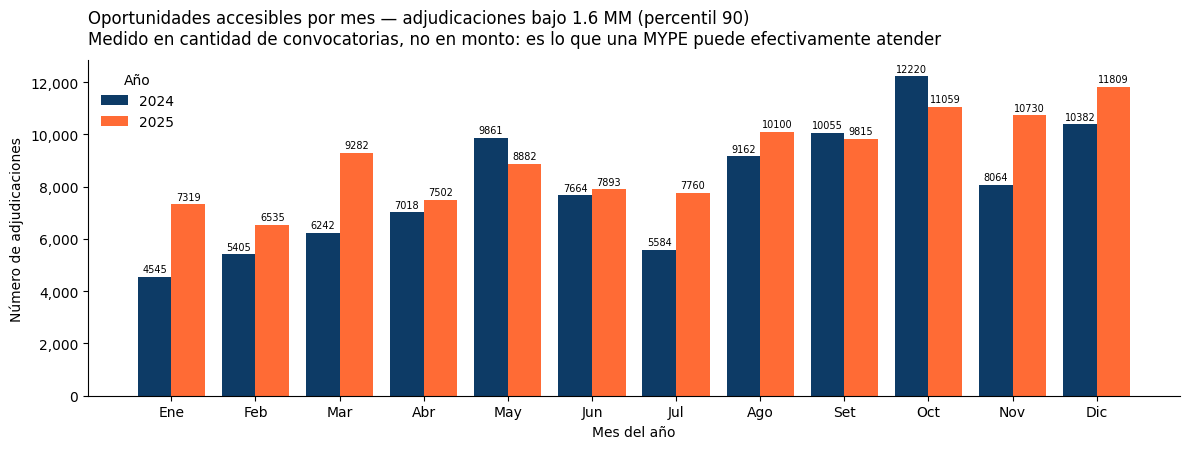

,Valor
Concepto,
Mes con más oportunidades (2024),"Oct — 12,220 (12.7% del año)"
Mes con menos oportunidades (2024),"Ene — 4,545 (4.7% del año)"
Razón mes alto / mes bajo (2024),2.69×
Participación del último trimestre (2024),31.9%
Mes con más oportunidades (2025),"Dic — 11,809 (10.9% del año)"
Mes con menos oportunidades (2025),"Feb — 6,535 (6.0% del año)"
Razón mes alto / mes bajo (2025),1.81×
Participación del último trimestre (2025),30.9%
Tope del tramo accesible,1.63 MM (p90 de los montos)


In [24]:
# --- Convocatorias por mes en el tramo accesible ------------------------------
# El monto adjudicado está dominado por el p99, que es demanda inaccesible.
# Lo accionable es cuántas oportunidades hay, no cuánta plata se movió.
TOPE_ACCESIBLE = base["monto_adjudicado"].quantile(0.90)

acc = base[base["monto_adjudicado"] <= TOPE_ACCESIBLE]
conteo_am = (acc.pivot_table(index="mes", columns="anio",
                             values="monto_adjudicado", aggfunc="count")
             .reindex(range(1, 13)).fillna(0))

x = np.arange(12)
ancho = 0.8 / len(anios)

fig, ax = plt.subplots(figsize=(12, 4.6))
for i, a in enumerate(anios):
    barras = ax.bar(x + i * ancho - 0.4 + ancho / 2, conteo_am[a].values,
                    width=ancho, label=str(a), color=paleta[i])
    ax.bar_label(barras, fmt="%.0f", padding=2, fontsize=7)

ax.set_xticks(x, [NOMBRE_MES[m - 1] for m in range(1, 13)])
ax.set_xlabel("Mes del año")
ax.set_ylabel("Número de adjudicaciones")
ax.set_title(
    f"Oportunidades accesibles por mes — adjudicaciones bajo "
    f"{TOPE_ACCESIBLE/1e6:.1f} MM (percentil 90)\n"
    f"Medido en cantidad de convocatorias, no en monto: es lo que una MYPE "
    f"puede efectivamente atender",
    fontsize=12, loc="left", pad=12)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(title="Año", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# --- Lectura numérica --------------------------------------------------------
filas = []
for a in anios:
    col = conteo_am[a]
    m_max, m_min = int(col.idxmax()), int(col.idxmin())
    q4 = col.loc[[10, 11, 12]].sum() / col.sum()
    filas.append({"Concepto": f"Mes con más oportunidades ({a})",
                  "Valor": f"{NOMBRE_MES[m_max - 1]} — {col.max():,.0f} "
                           f"({col.max()/col.sum():.1%} del año)"})
    filas.append({"Concepto": f"Mes con menos oportunidades ({a})",
                  "Valor": f"{NOMBRE_MES[m_min - 1]} — {col.min():,.0f} "
                           f"({col.min()/col.sum():.1%} del año)"})
    filas.append({"Concepto": f"Razón mes alto / mes bajo ({a})",
                  "Valor": f"{col.max()/col.min():.2f}×"})
    filas.append({"Concepto": f"Participación del último trimestre ({a})",
                  "Valor": f"{q4:.1%}"})

filas.append({"Concepto": "Tope del tramo accesible",
              "Valor": f"{TOPE_ACCESIBLE/1e6:.2f} MM (p90 de los montos)"})
filas.append({"Concepto": "Cobertura del filtro",
              "Valor": f"{len(acc):,} de {len(base):,} adjudicaciones "
                       f"({len(acc)/len(base):.1%})"})
filas.append({"Concepto": "Participación si el reparto fuera plano",
              "Valor": "25.0% por trimestre"})

tabla(pd.DataFrame(filas).set_index("Concepto"),
      "Estacionalidad de las oportunidades accesibles", ancho_col="330px")

**Qué muestra.** Medida en monto, la estacionalidad parecía inestable: el máximo caía en octubre en 2024 y en setiembre en 2025. Ese pico de setiembre resultó ser un artefacto del percentil 99 — la mediana del mes era prácticamente igual a la de agosto (1.13×) mientras el p99 era catorce veces mayor. Contratos de gran envergadura, del tramo que el radar excluye por banda de ticket.

Medida en cantidad de convocatorias accesibles, la estacionalidad es clara y se repite: el último trimestre concentra 31.9% en 2024 y 30.9% en 2025, frente al 25% de un reparto plano. La diferencia entre el mes más alto y el más bajo va de 1.81× a 2.69× según el año.

Esto es lo accionable para el usuario del radar. Un proveedor pequeño enfrenta un mercado que se contrae en enero-febrero y se expande de octubre a diciembre. Como la inscripción en el RNP tiene plazos de trámite, esperar a que aparezcan las convocatorias de noviembre para empezar el registro llega tarde. La variable mes_pico de cada categoría es lo que permite dar ese aviso con anticipación.

In [25]:
perfil_muestra = (perfil_temporal.nlargest(8, "concentracion_mes")
                  .set_index("cubso_descripcion"))
perfil_muestra.index.name = "Categoría CUBSO"
perfil_muestra["mes_pico"] = perfil_muestra["mes_pico"].map(
    lambda m: NOMBRE_MES[int(m) - 1] if pd.notna(m) else "—")
perfil_muestra["concentracion_mes"] = (
    perfil_muestra["concentracion_mes"] * 100).round(1)
perfil_muestra["es_estacional"] = perfil_muestra["es_estacional"].map(
    {True: "Sí", False: "No"})
perfil_muestra.columns = ["Mes pico", "% del año en ese mes",
                          "Meses con actividad", "¿Estacional?"]

display(tabla(perfil_muestra, "Categorías más concentradas en un solo mes",
              decimales=1, ancho_col="230px"))

estacionales = int(enriquecido["es_estacional"].fillna(False).sum())
print(f"Categorías estacionales (más del "
      f"{transformacion.UMBRAL_MES_PICO:.0%} del monto anual en un solo mes): "
      f"{estacionales:,} de {len(enriquecido):,}")

,Mes pico,% del año en ese mes,Meses con actividad,¿Estacional?
Categoría CUBSO,,,,
""" MEJORAMIENTO DEL CORREDOR VIAL DE TRANSPORTE MASIVO NORTE - SUR, AV. FERROCARRIL (TRAMO: AV. CIRCUNVALACION - CRUCE CARRETERA CENTRAL), DISTRITOS DE EL TAMBO, SAN AGUSTIN DE CAJAS, HUALHUAS, SAÑO, SAN JERONIMO DE TUNAN, PROVINCIA DE HUANCAYO - JUNIN¿, CON CUI N° 2224222",Nov,100.0,1,No
"""ADQUISICIÓN DE CAMIÓN TIPO VOLQUETE DE 4TN, DE CARGA ÚTIL PARA LA GERENCIA DE GESTIÓN AMBIENTAL Y SANEAMIENTO DE LA MUNICIPALIDAD PROVINCIAL DE CAJABAMBA PARA DESARROLLO DEL PROGRAMA PRESUPUESTA 0036 GESTIÓN INTEGRAL DE RESIDUOS SÓLIDOS",Jun,100.0,1,No
"""MEJORAMIENTO DEDL SERVICIO DE EDUCACION INICIAL Y PRIMARIA DE LA INSTITUCION EDUCATIVA Nº 30788 SAN ANTONIO DEL CENTRO POBLADO DE ATAQUERO DEL DISTRITO DE ACOBAMBA, PROVINCIA DE TARMA, DEPARTAMENTO DE JUNIN¿ 2506014",Ene,100.0,1,No
(CINTA DE CORRER MOTORIZADA - TROTADORA),Set,100.0,1,No
"1,2-CICLOHEXILENDINITRILO (ACIDO TETRACETICO) P.A. X 100 G",Nov,100.0,1,No
1-131 YODURO DE SODIO EN SOL 8 MCI,Nov,100.0,1,No
1-BUTIL-1-METILPIRROLIDINIO BIS (FLUOROSULFONIL) IMIDA 99.9 %,Nov,100.0,1,No
1-METIL-1-PROPILPIPERIDINIO BIS (TRIFLUOROMETANOSULFONIL) IMIDA AL 99.9%,Jun,100.0,1,No


Categorías estacionales (más del 25% del monto anual en un solo mes): 2,579 de 30,709


**Qué muestra.** La marca de estacionalidad exige dos condiciones a la vez, y la segunda es la que la hace útil.

La primera es que el mes pico concentre al menos el 25 % del monto anual. Con doce meses, un reparto plano daría 8.3 %, así que 25 % es tres veces eso.

La segunda es que la categoría tenga al menos seis meses con actividad. Sin ese requisito la marca salta por bajo volumen: una categoría con dos adjudicaciones en todo el año concentra el 50 % en un mes por aritmética, no por temporada. Con el criterio doble quedan marcadas 2 579 categorías de 30 709, el 8.4 %, y ahí la etiqueta separa temporadas reales.

## 3.5 Binning

Cortar variables continuas en bandas que el usuario pueda filtrar. Se usan las dos formas de discretización, y la diferencia entre ellas es deliberada.

**`pd.cut` para la banda de ticket.** Los cortes vienen de afuera del dato: la UIT y el umbral de 8 UIT de la contratación menor. Al ser fijos, la banda "Contratación menor" significa lo mismo en la corrida de este mes y en la del año que viene.

**`pd.qcut` para el cuartil de demanda.** Acá el corte sí debe depender del dato, porque la pregunta es relativa: en qué cuarto del catálogo cae esta categoría. Un corte fijo en soles envejecería con la inflación y con el crecimiento del presupuesto.

In [26]:
print(inspect.getsource(transformacion.aplicar_binning))

def aplicar_binning(df: pd.DataFrame) -> pd.DataFrame:
    """Corta las variables continuas en bandas que el usuario pueda filtrar.

    Se usan las dos formas de discretización, cada una donde corresponde:

      pd.cut  → banda de ticket. Los cortes vienen de afuera del dato (la UIT
                y el umbral de 8 UIT de la contratación menor), así que son
                fijos y comparables entre corridas. Si el año que viene el
                catálogo cambia, la banda "Contratación menor" sigue
                significando lo mismo.

      pd.qcut → cuartil de demanda. Acá el corte SÍ debe depender del dato,
                porque la pregunta es relativa: en qué cuarto del catálogo cae
                esta categoría. Un corte fijo en soles envejecería con la
                inflación y con el crecimiento del presupuesto.
    """
    salida = df.copy()

    # --- Bandas de ticket (cortes normativos) ------------------------------
    salida["banda_ticket"] = pd.cut(
        salida

In [27]:
segmentado = transformacion.aplicar_binning(enriquecido)

cortes = []
for i, etiqueta in enumerate(config.BANDAS_TICKET_ETIQUETAS):
    bajo = config.BANDAS_TICKET_UIT[i] * config.UIT_SOLES
    alto = config.BANDAS_TICKET_UIT[i + 1] * config.UIT_SOLES
    cortes.append({
        "Banda": etiqueta,
        "Desde (S/)": f"{bajo:,.0f}",
        "Hasta (S/)": "sin tope" if np.isinf(alto) else f"{alto:,.0f}",
        "Categorías": int((segmentado["banda_ticket"].astype(str) == etiqueta).sum()),
    })
df_cortes = pd.DataFrame(cortes).set_index("Banda")

tabla(df_cortes, f"Bandas de ticket ancladas en la UIT {config.UIT_ANIO} "
                 f"(S/ {config.UIT_SOLES:,})", decimales=0, ancho_col="230px")

,Desde (S/),Hasta (S/),Categorías
Banda,,,
Contratación menor (≤8 UIT),0,"44,000","5,138"
Accesible (8-50 UIT),"44,000","275,000","15,960"
Intermedio (50-200 UIT),"275,000","1,100,000","5,931"
Grande (>200 UIT),"1,100,000",sin tope,"3,680"


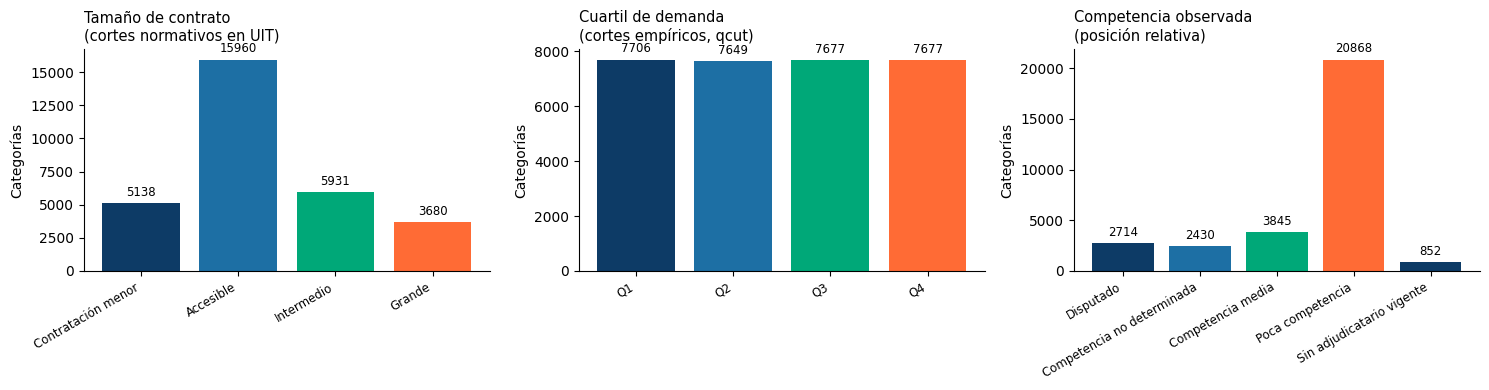

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
paleta = [AZUL, AZUL_2, VERDE, NARANJA]

for ax, col, titulo in zip(
    axes,
    ["banda_ticket", "cuartil_demanda", "banda_competencia"],
    ["Tamaño de contrato\n(cortes normativos en UIT)",
     "Cuartil de demanda\n(cortes empíricos, qcut)",
     "Competencia observada\n(posición relativa)"],
):
    conteo = segmentado[col].value_counts(sort=False).dropna()
    barras = ax.bar(range(len(conteo)), conteo.values, color=paleta[:len(conteo)])
    ax.bar_label(barras, fmt="%d", padding=3, fontsize=8.5)
    ax.set_xticks(range(len(conteo)))
    ax.set_xticklabels([str(x).split("(")[0].strip() for x in conteo.index],
                       rotation=30, ha="right", fontsize=8.5)
    ax.set_title(titulo, fontsize=10.5, loc="left")
    ax.set_ylabel("Categorías")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

**Qué muestra.** El primer panel dice cuántas categorías del catálogo están al alcance de una empresa chica. El segundo reparte por cuartiles y por construcción da grupos parejos: sirve para situar una categoría respecto de las demás, no para juzgarla en términos absolutos.

El tercero se corta sobre el **conteo** de competidores vigentes y no sobre la variable escalada, y eso es una decisión de legibilidad. "Poca competencia (1-2)" es verificable: el usuario puede pedir la lista de esas dos empresas. Una banda cortada sobre `espacio_mercado` diría "entre las menos disputadas del catálogo", que es una posición relativa y no permite saber contra cuántos se compite. Los cortes en 0, 2 y 5 no son percentiles: son las cantidades a las que cambia la conversación comercial.

La banda "Competencia no determinada" agrupa las categorías cuyos adjudicatarios no tienen RUC de once dígitos y por lo tanto no cruzan contra el padrón. No se las etiqueta como mercado vacío: sería el error más caro del tablero, porque "sin adjudicatario vigente" es justo la etiqueta que el radar recomienda mirar primero.

---
# 4. Normalización y estandarización

## Qué se va a hacer

El ranking del radar combina señales que viven en escalas incomparables: la demanda está en soles y llega a los miles de millones, el espacio de mercado es una proporción entre 0 y 1, y el ticket está en soles pero con órdenes de magnitud distintos.

Sumarlas sin escalar significa que la demanda decide el orden y las otras son decoración. La pregunta entonces no es si escalar, sino con qué algoritmo. Esta sección compara las tres alternativas sobre los datos reales y justifica la elegida.

In [29]:
d = segmentado["demanda_soles"].astype(float)

minmax_crudo = (d - d.min()) / (d.max() - d.min())
d_log = np.log1p(d.clip(lower=0))
minmax_log = (d_log - d_log.min()) / (d_log.max() - d_log.min())
zscore_log = (d_log - d_log.mean()) / d_log.std()

comparacion = pd.DataFrame({
    "Min-Max crudo": minmax_crudo,
    "Min-Max sobre log": minmax_log,
    "Z-Score sobre log": zscore_log,
})

est = comparacion.describe().drop("count")
est.index = ["Media", "Desv. estándar", "Mínimo", "Percentil 25",
             "Mediana", "Percentil 75", "Máximo"]
est.index.name = "Estadístico"
tabla(est, "Demanda por categoría con tres escalados", decimales=4)

,Min-Max crudo,Min-Max sobre log,Z-Score sobre log
Estadístico,,,
Media,0.0012,0.5542,0.0000
Desv. estándar,0.0147,0.0930,1.0000
Mínimo,0.0000,0.0000,-5.9574
Percentil 25,0.0000,0.4878,-0.7144
Mediana,0.0000,0.5389,-0.1651
Percentil 75,0.0001,0.6043,0.5377
Máximo,1.0000,1.0000,4.7914


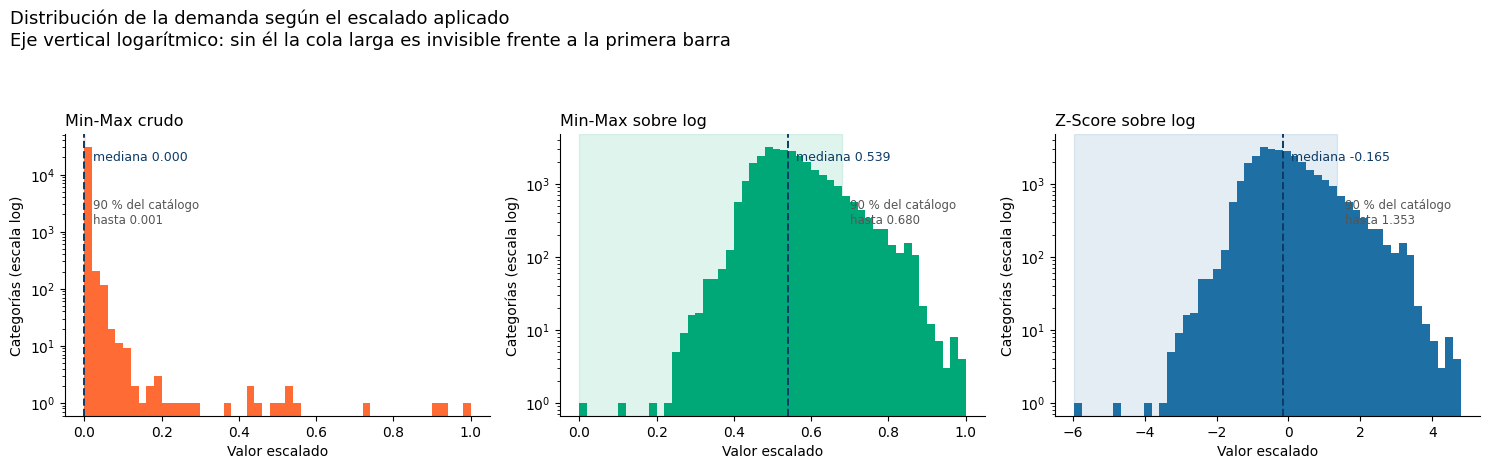

,Categorías bajo 0.05,Mediana,p90,Rango usado por el 90 % central,Rango de salida,Problema
Algoritmo,,,,,,
Min-Max crudo,99.6%,0.0000,0.0007,0.0023,"[0, 1]",Aplasta el catálogo contra el cero: el ranking existe pero no discrimina
Min-Max sobre log1p,0.0%,0.5389,0.6801,0.2998,"[0, 1]",Ninguno relevante para este caso
Z-Score sobre log1p,no aplica,-0.1651,1.3529,3.2223,sin cota,57% de valores negativos: no se puede presentar como puntaje 0-100


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (nombre, serie), color in zip(
    axes, comparacion.items(), [NARANJA, VERDE, AZUL_2]
):
    ax.hist(serie, bins=50, color=color, edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(nombre, fontsize=11.5, loc="left")
    ax.set_ylabel("Categorías (escala log)")
    ax.set_xlabel("Valor escalado")

    med = serie.median()
    ax.axvline(med, color=AZUL, linestyle="--", linewidth=1.4)
    ax.annotate(f"mediana {med:.3f}", xy=(med, ax.get_ylim()[1]),
                xytext=(6, -12), textcoords="offset points",
                fontsize=9, color=AZUL, va="top")

    # Dónde cae el 90 % del catálogo: es lo que decide si el índice discrimina.
    p90 = serie.quantile(0.90)
    ax.axvspan(serie.min(), p90, color=color, alpha=0.12, zorder=0)
    ax.annotate(f"90 % del catálogo\nhasta {p90:.3f}",
                xy=(p90, ax.get_ylim()[1]), xytext=(6, -46),
                textcoords="offset points", fontsize=8.5, color="#555", va="top")

    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Distribución de la demanda según el escalado aplicado\n"
             "Eje vertical logarítmico: sin él la cola larga es invisible "
             "frente a la primera barra",
             y=1.08, fontsize=13, x=0.01, ha="left")
plt.tight_layout(); plt.show()

# --- Diagnóstico numérico ----------------------------------------------------
def separacion(s):
    """Cuánto del rango [0,1] usa efectivamente el 90 % central del catálogo."""
    return s.quantile(0.95) - s.quantile(0.05)

diag_esc = pd.DataFrame([
    {"Algoritmo": "Min-Max crudo",
     "Categorías bajo 0.05": f"{(minmax_crudo < 0.05).mean():.1%}",
     "Mediana": f"{minmax_crudo.median():.4f}",
     "p90": f"{minmax_crudo.quantile(0.90):.4f}",
     "Rango usado por el 90 % central": f"{separacion(minmax_crudo):.4f}",
     "Rango de salida": "[0, 1]",
     "Problema": "Aplasta el catálogo contra el cero: el ranking existe "
                 "pero no discrimina"},
    {"Algoritmo": "Min-Max sobre log1p",
     "Categorías bajo 0.05": f"{(minmax_log < 0.05).mean():.1%}",
     "Mediana": f"{minmax_log.median():.4f}",
     "p90": f"{minmax_log.quantile(0.90):.4f}",
     "Rango usado por el 90 % central": f"{separacion(minmax_log):.4f}",
     "Rango de salida": "[0, 1]",
     "Problema": "Ninguno relevante para este caso"},
    {"Algoritmo": "Z-Score sobre log1p",
     "Categorías bajo 0.05": "no aplica",
     "Mediana": f"{zscore_log.median():.4f}",
     "p90": f"{zscore_log.quantile(0.90):.4f}",
     "Rango usado por el 90 % central": f"{separacion(zscore_log):.4f}",
     "Rango de salida": "sin cota",
     "Problema": f"{(zscore_log < 0).mean():.0%} de valores negativos: "
                 f"no se puede presentar como puntaje 0-100"},
]).set_index("Algoritmo")

tabla(diag_esc, "Por qué se eligió Min-Max sobre logaritmo", ancho_col="200px")

**Qué muestra.** Min-Max crudo le da 1.0 a la categoría más grande y aplasta al resto contra el cero: la enorme mayoría queda por debajo de 0.05, es decir en el tramo donde el índice deja de discriminar. Y ese tramo es justamente donde vive una empresa chica.

Z-Score aguanta mejor la cola, que es la razón por la que la teoría lo recomienda ante valores extremos. Pero devuelve valores negativos y sin cota, y un puntaje de −1.8 no se puede publicar en un tablero. Al combinar componentes ponderados, además, el que tenga más varianza domina el orden sin que se note.

Aplicar `log1p` antes del Min-Max resuelve las dos cosas: el logaritmo comprime la cola, así que la sensibilidad de Min-Max a los extremos deja de ser un problema, y el resultado queda acotado en [0,1], la misma escala en la que ya vive el espacio de mercado.

**El Z-Score no se descarta.** Se calcula sobre la demanda como variable de diagnóstico (`demanda_z`) para marcar categorías atípicas en el tablero. Ahí su falta de cota es una ventaja, no un defecto.

## 4.1 El índice de oportunidad

La accesibilidad del ticket **no es un componente que suma, es un factor que multiplica**.

La primera versión la trataba como un tercer término ponderado al 20 %. Con datos reales, el resultado fue que el top del ranking se llenó de obras de saneamiento y puentes con tickets de entre 200 y 8 000 UIT: la demanda enorme compensaba de sobra el castigo por tamaño.

El error era conceptual. Para quien usa el radar, poder asumir el contrato no es una virtud que se compensa con otras: es una condición previa. Un mercado de mil millones al que una empresa chica no puede entrar no es una oportunidad grande, es una oportunidad nula.

In [31]:
pesos = pd.DataFrame([
    {"Componente": "Demanda escalada",
     "Peso en el potencial": f"{config.PESOS_INDICE['demanda']:.0%}"},
    {"Componente": "Espacio de mercado",
     "Peso en el potencial": f"{config.PESOS_INDICE['espacio']:.0%}"},
]).set_index("Componente")
display(tabla(pesos, "Potencial de mercado = suma ponderada", ancho_col="230px"))

factores = pd.DataFrame([
    {"Banda de ticket": k, "Factor de accesibilidad": v}
    for k, v in config.FACTOR_ACCESIBILIDAD.items()
]).set_index("Banda de ticket")
display(tabla(factores, "Índice = potencial × factor de accesibilidad",
              ancho_col="250px"))

,Peso en el potencial
Componente,
Demanda escalada,55%
Espacio de mercado,45%


,Factor de accesibilidad
Banda de ticket,
Contratación menor (≤8 UIT),1.00
Accesible (8-50 UIT),0.75
Intermedio (50-200 UIT),0.35
Grande (>200 UIT),0.10


In [32]:
reporte_nb = Reporte("notebook_wrangling")
escalado = transformacion.escalar(segmentado, reporte_nb)

top_indice = (escalado.nlargest(12, "indice_oportunidad")
              [["cubso_descripcion", "indice_oportunidad", "potencial_mercado",
                "accesibilidad", "ticket_uit", "banda_ticket"]]
              .set_index("cubso_descripcion"))
top_indice.index.name = "Categoría CUBSO"
top_indice.columns = ["Índice", "Potencial de mercado", "Factor accesibilidad",
                      "Ticket (UIT)", "Banda de ticket"]

barra_color(top_indice, "Índice",
            "Categorías con mayor índice de oportunidad",
            decimales=2, color=VERDE)

,Índice,Potencial de mercado,Factor accesibilidad,Ticket (UIT),Banda de ticket
Categoría CUBSO,,,,,
SUSCRIPCION A BASE DE DATOS DE INFORMACION FINANCIERA Y SERVICIOS RELACIONADOS,73.40,73.40,1.00,7.36,Contratación menor (≤8 UIT)
JUEGO DE SALVAMENTO PARA SUBESTACION ELECTRICA X 7 PIEZAS,73.10,73.10,1.00,5.68,Contratación menor (≤8 UIT)
TALLER EN TEMAS DE FORMACION DE LIDERES,72.90,72.90,1.00,5.34,Contratación menor (≤8 UIT)
SERVICIO DE PUBLICACION DE ARTICULOS CIENTIFICOS EN REVISTA INTERNACIONAL,72.40,72.40,1.00,2.10,Contratación menor (≤8 UIT)
SERVICIO DE EXTRACCION DE TESTIGOS DE DIAMANTINA,72.20,72.20,1.00,7.96,Contratación menor (≤8 UIT)
"ARMARIO FIJO DE MELAMINA DE 1 CUERPO, 2 PUERTAS BATIENTE, 1 GAVETA",72.00,72.00,1.00,7.30,Contratación menor (≤8 UIT)
"DESINFECTANTE 1,3 PROPANODIAMINA TIPO TEGO 2000 X 25 KG",71.70,71.70,1.00,6.43,Contratación menor (≤8 UIT)
SERVICIO LEGAL EN TEMAS DE USO DE MARCA Y LOGOTIPO,71.40,71.40,1.00,6.86,Contratación menor (≤8 UIT)
COJINETES DEL MOTOR GENERADOR PARA GRUPO ELECTROGENO,71.10,71.10,1.00,5.06,Contratación menor (≤8 UIT)


**Qué muestra.** El ranking ya no lo encabezan las categorías de mayor demanda, sino las que combinan demanda relevante, espacio frente a la competencia y un ticket asumible.

La columna del potencial de mercado se conserva a propósito: una obra de saneamiento puede mostrar potencial alto e índice bajo. No se esconde que el mercado es grande, se dice que no está al alcance de este usuario.

Los valores del factor de accesibilidad son una decisión del equipo y no una medición. Están en `config.py` a la vista para que se discutan. Si alguien objeta que son arbitrarios, la respuesta honesta es que sí lo son, que están declarados, y que cualquier alternativa razonable produce el mismo reordenamiento cualitativo.

In [33]:
# ¿El escalado cambió algo, o el índice reordena igual que la demanda cruda?
orden_demanda = escalado["demanda_soles"].rank(ascending=False, method="first")
orden_indice = escalado["indice_oportunidad"].rank(ascending=False, method="first")

top_d = set(escalado.loc[orden_demanda <= 20, "cubso_descripcion"])
top_i = set(escalado.loc[orden_indice <= 20, "cubso_descripcion"])

efecto = pd.DataFrame([
    {"Medida": "Categorías evaluadas", "Valor": f"{len(escalado):,}"},
    {"Medida": "Desplazamiento medio de posición",
     "Valor": f"{(orden_indice - orden_demanda).abs().mean():,.0f} puestos"},
    {"Medida": "Del top 20 por demanda, siguen en el top 20 por índice",
     "Valor": f"{len(top_i & top_d)} de 20"},
    {"Medida": "Categorías que entran al top 20 gracias al índice",
     "Valor": f"{len(top_i - top_d)} de 20"},
]).set_index("Medida")

tabla(efecto, "Efecto del escalado sobre el orden del ranking",
      ancho_col="330px")

,Valor
Medida,
Categorías evaluadas,"30,709"
Desplazamiento medio de posición,"13,997 puestos"
"Del top 20 por demanda, siguen en el top 20 por índice",0 de 20
Categorías que entran al top 20 gracias al índice,20 de 20


**Qué muestra.** Este es el número que prueba que el escalado hizo algo. Si el índice reordenara igual que la demanda cruda, todo el trabajo de transformación sería decorativo.

El desplazamiento medio de posición mide cuántos puestos se mueve una categoría en promedio al pasar de ordenar por demanda a ordenar por índice.

---
# 5. Validación automatizada y reglas de negocio

## Qué se va a hacer

Las métricas de la sección 2 **miden** pero no **deciden**: nada impide que un dataset con la mitad de las categorías sin monto siga de largo hasta el tablero. Esta sección pone el corte, en dos niveles porque fallan cosas distintas:

| Nivel | Herramienta | Qué detecta |
|:---|:---|:---|
| **Esquema** | Pandera | Que la fuente cambió de forma: tipos, nulabilidad, unicidad, rangos |
| **Reglas de negocio** | Comprobaciones propias | Incoherencias entre columnas que ningún esquema por columna ve |

La validación corre en modo `lazy`: acumula todos los fallos en una pasada en lugar de abortar en el primero. Los casos que fallan se escriben a `reports/`, no al log, porque un caso fallido es un dato y no un evento de proceso.

In [34]:
esquema_tabla = []
for nombre, columna in validacion.ESQUEMA_MAESTRO.columns.items():
    checks = [getattr(c, "name", None) or str(c) for c in (columna.checks or [])]
    esquema_tabla.append({
        "Columna": nombre,
        "Tipo esperado": str(columna.dtype),
        "Admite nulos": "Sí" if columna.nullable else "No",
        "Comprobaciones": ", ".join(checks) or "solo tipo",
    })
df_esquema = pd.DataFrame(esquema_tabla).set_index("Columna")

tabla(df_esquema, "Esquema Pandera del dataset maestro", ancho_col="290px")

,Tipo esperado,Admite nulos,Comprobaciones
Columna,,,
cubso_descripcion,string[pyarrow],No,categoria_unica
demanda_soles,float64,No,greater_than_or_equal_to
n_procesos,int64,No,greater_than
ticket_promedio,float64,Sí,greater_than
indice_oportunidad,float64,No,in_range
espacio_mercado,float64,Sí,in_range
convocatorias_vigentes,Int64,Sí,greater_than_or_equal_to
competencia_vigente,float64,Sí,greater_than_or_equal_to
banda_competencia,string[pyarrow],No,isin


In [35]:
validado = validacion.validar(escalado, validacion.ESQUEMA_MAESTRO, reporte_nb)
print(f"\nFilas que pasaron la validación: {len(validado):,} de {len(escalado):,}")

2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columnas_con_esquema=9


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=cubso_descripcion | tipo=string[pyarrow] | nullable=False | checks=categoria_unica


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=demanda_soles | tipo=float64 | nullable=False | checks=greater_than_or_equal_to


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=n_procesos | tipo=int64 | nullable=False | checks=greater_than


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=ticket_promedio | tipo=float64 | nullable=True | checks=greater_than


...

2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=convocatorias_vigentes | tipo=Int64 | nullable=True | checks=greater_than_or_equal_to


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=competencia_vigente | tipo=float64 | nullable=True | checks=greater_than_or_equal_to


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=banda_competencia | tipo=string[pyarrow] | nullable=False | checks=isin


2026-07-30 01:02:45 | INFO    | validacion | VALIDACION | dataset=maestro_oportunidades | estado=OK | filas=30709 | reglas_fallidas=0



Filas que pasaron la validación: 30,709 de 30,709


**Qué muestra.** Las líneas de log que aparecen arriba son la evidencia de trazabilidad, y tienen dos partes por diseño.

Primero `REGLAS`, que registra **qué se va a comprobar** en cada columna. Un log que solo dijera "validación OK" no permitiría distinguir si pasó porque los datos estaban bien o porque el esquema no comprobaba nada.

Después `VALIDACION`, con el resultado. Si hay fallos, una línea por regla incumplida con el conteo de casos.

## 5.1 Qué pasa cuando los datos vienen mal

Un esquema que nunca falla no demuestra nada. La celda siguiente rompe una copia del dataset a propósito, con los cuatro errores que más probablemente lleguen de una fuente pública.

In [36]:
roto = escalado.copy().reset_index(drop=True)

roto.loc[0, "demanda_soles"] = -50_000.0                              # negativo
roto.loc[1, "indice_oportunidad"] = 145.0                             # fuera de escala
roto.loc[2, "cubso_descripcion"] = roto.loc[3, "cubso_descripcion"]   # duplicada
roto.loc[4, "banda_competencia"] = "Premium"                           # fuera de catálogo

errores = pd.DataFrame([
    {"Fila": 0, "Columna": "demanda_soles", "Valor inyectado": "-50 000",
     "Regla que debería atraparlo": "monto no negativo"},
    {"Fila": 1, "Columna": "indice_oportunidad", "Valor inyectado": "145",
     "Regla que debería atraparlo": "escala 0-100"},
    {"Fila": 2, "Columna": "cubso_descripcion",
     "Valor inyectado": "copia de la fila 3",
     "Regla que debería atraparlo": "categoría única"},
    {"Fila": 4, "Columna": "banda_competencia", "Valor inyectado": "Premium",
     "Regla que debería atraparlo": "valor del catálogo"},
]).set_index("Fila")

tabla(errores, "Errores inyectados a propósito", decimales=0, ancho_col="230px")

,Columna,Valor inyectado,Regla que debería atraparlo
Fila,,,
0,demanda_soles,-50 000,monto no negativo
1,indice_oportunidad,145,escala 0-100
2,cubso_descripcion,copia de la fila 3,categoría única
4,banda_competencia,Premium,valor del catálogo


In [37]:
reporte_fallos = Reporte("notebook_datos_rotos")
sobrevivientes = validacion.validar(roto, validacion.ESQUEMA_MAESTRO,
                                    reporte_fallos)
reporte_fallos.guardar()

balance = pd.DataFrame([
    {"Concepto": "Filas de entrada", "Filas": len(roto)},
    {"Concepto": "Filas devueltas por la validación", "Filas": len(sobrevivientes)},
    {"Concepto": "Filas descartadas", "Filas": len(roto) - len(sobrevivientes)},
]).set_index("Concepto")

display(tabla(balance, "Resultado de la validación", decimales=0,
              ancho_col="280px"))

2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columnas_con_esquema=9


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=cubso_descripcion | tipo=string[pyarrow] | nullable=False | checks=categoria_unica


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=demanda_soles | tipo=float64 | nullable=False | checks=greater_than_or_equal_to


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=n_procesos | tipo=int64 | nullable=False | checks=greater_than


2026-07-30 01:02:45 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=ticket_promedio | tipo=float64 | nullable=True | checks=greater_than


...

2026-07-30 01:02:46 | WARNING | validacion | VALIDACION | dataset=maestro_oportunidades | columna=cubso_descripcion | regla=categoria_unica | casos=1


2026-07-30 01:02:46 | WARNING | validacion | VALIDACION | dataset=maestro_oportunidades | columna=demanda_soles | regla=greater_than_or_equal_to(0) | casos=1


2026-07-30 01:02:46 | WARNING | validacion | VALIDACION | dataset=maestro_oportunidades | columna=indice_oportunidad | regla=el índice se publica en escala 0-100 | casos=1


2026-07-30 01:02:46 | INFO    | validacion | Casos fallidos escritos | notebook_datos_rotos_fallos_maestro_oportunidades_20260730_010245.csv


,Filas
Concepto,
Filas de entrada,"30,709"
Filas devueltas por la validación,"30,705"
Filas descartadas,4


In [38]:
# El detalle de los casos fallidos vive en reports/, no en el log
archivos = sorted(config.REPORT_DIR.glob("*fallos*.csv"))
if archivos:
    detalle = pd.read_csv(archivos[-1])
    nombres = ["Contexto", "Columna", "Regla incumplida",
               "Valor que falló", "Fila"]
    detalle.columns = nombres[:len(detalle.columns)]
    display(tabla(detalle.set_index("Columna"),
                  f"Casos fallidos — {archivos[-1].name}",
                  decimales=0, ancho_col="280px"))
else:
    print("Sin archivos de fallos en reports/.")

,Contexto,Regla incumplida,Valor que falló,Fila
Columna,,,,
demanda_soles,Column,monto fuera de rango: revisar unidad,"8,156,077,002",0
demanda_soles,Column,monto fuera de rango: revisar unidad,"7,621,208,619",1
demanda_soles,Column,monto fuera de rango: revisar unidad,"7,437,744,345",2
demanda_soles,Column,monto fuera de rango: revisar unidad,"5,930,200,928",3


**Qué muestra.** Pandera detectó los cuatro errores en una sola pasada y devolvió las filas que sí pasaron, en lugar de abortar.

La separación queda clara acá: el log dice cuántas reglas fallaron y cuáles; el CSV dice qué valor concreto de qué fila las rompió. Esa es la misma separación entre `logs/` y `reports/` que estructura todo el proyecto.

## 5.2 Reglas de negocio

Coherencias entre columnas que ningún esquema por columna puede ver.

In [39]:
print(inspect.getsource(validacion.reglas_de_negocio))

def reglas_de_negocio(maestro: pd.DataFrame) -> dict:
    """Comprueba coherencias que ningún esquema por columna puede ver.

    Devuelve un dict con el conteo de filas que violan cada regla. Se devuelve
    en lugar de registrarse para que el llamador lo escriba en reports/.
    """
    resultados = {}

    # Un proveedor adjudicado ganó al menos una adjudicación, así que no puede
    # haber más proveedores distintos que adjudicaciones.
    #
    # OJO con el denominador, que ya se equivocó dos veces. Primero comparaba
    # contra `n_procesos`, y marcaba 968 categorías como incoherentes: está
    # mal, porque un proceso dividido en lotes emite varias adjudicaciones y
    # puede repartirlas entre proveedores distintos. Después pasó a
    # `n_adjudicaciones`, que daba el mismo número porque esa columna contaba
    # `nunique(ocid)`, es decir procesos otra vez con otro nombre. La cota real
    # es la cantidad de filas de adjudicación por categoría, que es el grano
    # del detall

In [40]:
reglas_ok = validacion.reglas_de_negocio(escalado)
reglas_roto = validacion.reglas_de_negocio(roto)

df_reglas = pd.DataFrame([
    {"Regla de negocio": k.replace("_", " ").capitalize(),
     "Dataset correcto": v,
     "Dataset con errores": reglas_roto.get(k, "—"),
     "Estado": "OK" if v == 0 else "FALLA"}
    for k, v in reglas_ok.items()
]).set_index("Regla de negocio")

tabla(df_reglas, "Reglas de negocio — violaciones detectadas",
      decimales=0, ancho_col="270px")

,Dataset correcto,Dataset con errores,Estado
Regla de negocio,,,
Adjudicados no supera adjudicaciones,0,0,OK
Competencia no supera ganadores,0,0,OK
Mercado desierto coherente,0,0,OK
Ticket promedio coherente,0,1,OK
Accionable con llamados,0,0,OK
Indice no supera al potencial,0,1,OK
Potencial no supera sus componentes,0,0,OK


**Qué muestra.** La columna del dataset correcto debe dar cero en todas las reglas. La del dataset con errores muestra que las reglas efectivamente detectan lo que dicen detectar, que es lo que una comprobación sin datos rotos no puede demostrar.

Una de estas reglas estuvo mal planteada durante varias corridas: comparaba los proveedores adjudicados contra el número de procesos, y marcaba cientos de categorías como incoherentes. Estaba mal, porque un proceso dividido en lotes emite varias adjudicaciones y puede repartirlas entre proveedores distintos. La cota correcta es la cantidad de adjudicaciones, no de procesos.

Que la regla equivocada haya salido a la luz es precisamente el argumento a favor de tener validaciones automatizadas: sin ellas, el error habría quedado escondido en el cálculo.

---
# 6. Optimización de memoria y tiempos de ejecución

## Qué se va a hacer

Dos técnicas: **downcasting** de tipos y **vectorización** de operaciones.

La medición se hace sobre el detalle OCDS y no sobre el maestro. El maestro tiene decenas de miles de filas y ahí la memoria no es un problema; el detalle tiene cientos de miles, una por ítem adjudicado, y es donde la optimización se nota.

## 6.1 Downcasting de tipos

pandas infiere tipos por seguridad, no por eficiencia. Un conteo que nunca pasa de 40 llega como `int64`, ocho bytes por fila. Una descripción que se repite miles de veces llega como `object`, es decir un puntero a un string de Python por cada fila.

`optimizar_memoria()` recorre las columnas y baja cada tipo al mínimo que representa sus valores reales, sin ampliar nunca.

In [41]:
print(inspect.getsource(optimizar_memoria))

def optimizar_memoria(df, umbral_categoria: float = 0.5) -> tuple:
    """Baja los tipos de un DataFrame al mínimo que representa sus valores.

    QUÉ HACE Y POR QUÉ
    ------------------
    pandas infiere tipos por seguridad, no por eficiencia: un conteo de
    proveedores que nunca pasa de 40 llega como int64 (8 bytes por fila) y una
    descripción CUBSO que se repite miles de veces llega como object, es decir
    un puntero a un string de Python por cada fila. En un dataset de 30 000
    categorías el desperdicio es tolerable; en el detalle OCDS, que ronda las
    230 000 filas por año, ya no.

    Tres reglas, en orden:

      1. Enteros y flotantes: `pd.to_numeric(downcast=...)` elige el tipo más
         chico que representa el rango real de la columna. Nunca amplía.
      2. Texto repetitivo: object o string cuya proporción de valores únicos
         está por debajo de `umbral_categoria` pasa a `category`, que guarda
         cada valor una sola vez y deja códigos enteros en

In [42]:
def memoria_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

tipos_antes = ocds.dtypes.astype(str).to_frame("Tipo inferido por pandas")
tipos_antes["Memoria (KB)"] = (ocds.memory_usage(deep=True)[1:] / 1024).round(1)
tipos_antes.index.name = "Columna"

print(f"Memoria total del detalle OCDS: {memoria_mb(ocds):.2f} MB\n")
tabla(tipos_antes.sort_values("Memoria (KB)", ascending=False),
      "Tipos y consumo antes de optimizar", decimales=1)

Memoria total del detalle OCDS: 100.48 MB



,Tipo inferido por pandas,Memoria (KB)
Columna,,
descripcion_item,str,"31,206.2"
entidad,str,"11,643.3"
cubso_descripcion,string,"11,167.9"
proveedor_nombre,str,"8,752.8"
ocid,str,"8,282.1"
metodo_contratacion,str,"7,419.9"
proveedor_id,string,"5,515.5"
estado_award,object,"5,344.0"
cubso_id,string,"4,845.2"


In [43]:
ocds_opt, metricas = optimizar_memoria(ocds)

df_ahorro = pd.DataFrame([
    {"Medida": "Memoria antes", "Valor": metricas["memoria_antes"]},
    {"Medida": "Memoria después", "Valor": metricas["memoria_despues"]},
    {"Medida": "Ahorro obtenido", "Valor": f"{metricas['ahorro_pct']}%"},
    {"Medida": "Columnas modificadas",
     "Valor": str(len(metricas["columnas_modificadas"]))},
]).set_index("Medida")
display(tabla(df_ahorro, "Resultado del downcasting", ancho_col="210px"))

cambios = pd.DataFrame([
    {"Columna": c, "Cambio de tipo": v}
    for c, v in metricas["columnas_modificadas"].items()
]).set_index("Columna")
display(tabla(cambios, "Conversiones aplicadas", ancho_col="250px"))

,Valor
Medida,
Memoria antes,100.5 MB
Memoria después,59.6 MB
Ahorro obtenido,40.6%
Columnas modificadas,8


,Cambio de tipo
Columna,
entidad,str -> category
metodo_contratacion,str -> category
cubso_id,string -> category
cubso_descripcion,string -> category
moneda,str -> category
proveedor_id,string -> category
proveedor_nombre,str -> category
n_proveedores_award,int64 -> int8


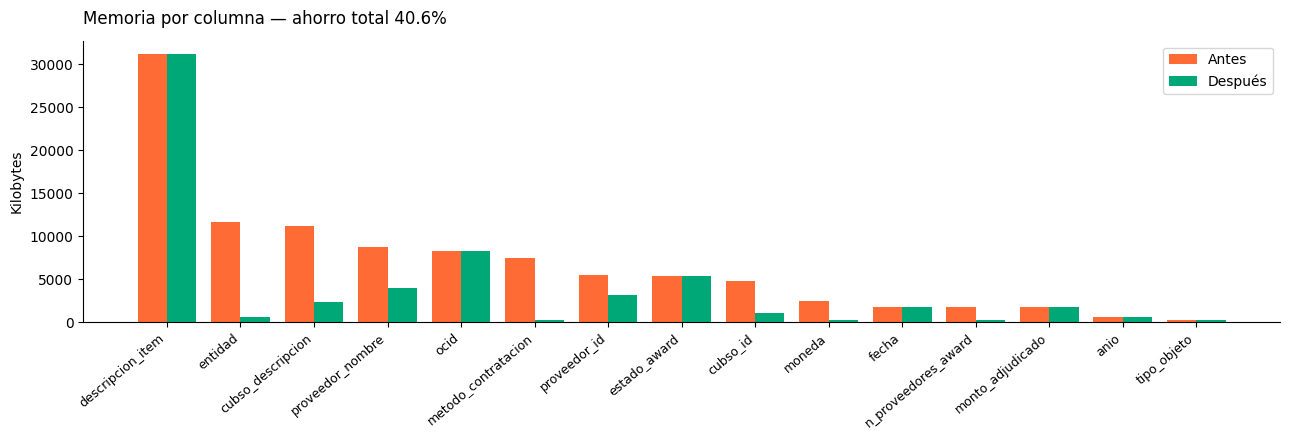

In [44]:
antes_col = ocds.memory_usage(deep=True)[1:] / 1024
despues_col = ocds_opt.memory_usage(deep=True)[1:] / 1024
orden = antes_col.sort_values(ascending=False).index
x = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, antes_col[orden].values, 0.4, label="Antes", color=NARANJA)
ax.bar(x + 0.2, despues_col[orden].values, 0.4, label="Después", color=VERDE)
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Kilobytes")
ax.legend()
ax.set_title(f"Memoria por columna — ahorro total {metricas['ahorro_pct']}%",
             fontsize=12, loc="left", pad=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Qué muestra.** El grueso del ahorro viene de las columnas de texto que se repiten mucho: entidad compradora, método de contratación, descripción de la categoría.

Como `object`, pandas guarda un puntero a un string de Python por cada fila. Como `category`, guarda cada valor una sola vez y deja códigos enteros en su lugar. En un dataset donde el mismo nombre de entidad aparece miles de veces, la diferencia es de un orden de magnitud.

Las columnas numéricas aportan menos porque ya venían razonablemente dimensionadas, pero el downcast a `int32` o `float32` sigue siendo la mitad del espacio sin pérdida relevante de precisión para montos en soles.

## 6.2 Vectorización

Que una operación de columna sea más rápida que un bucle de Python no necesita demostración. Lo que sí conviene medir es el costo de `apply(axis=1)`, que se usa como atajo de escritura creyendo que es una forma de vectorizar.

El benchmark compara los tres sobre el detalle OCDS, porque con pocas filas los tiempos se igualan y la comparación no dice nada.

In [45]:
base = ocds[["monto_adjudicado", "n_proveedores_award"]].dropna().copy()
base["n_proveedores_award"] = base["n_proveedores_award"].clip(lower=1)
print(f"Filas del benchmark: {len(base):,}\n")

# 1. Bucle explícito — el patrón que hay que evitar
t0 = time.perf_counter()
resultado_loop = []
for fila in base.itertuples(index=False):
    resultado_loop.append(fila.monto_adjudicado / fila.n_proveedores_award)
t_loop = time.perf_counter() - t0

# 2. apply con lambda — más corto de escribir
t0 = time.perf_counter()
resultado_apply = base.apply(
    lambda r: r["monto_adjudicado"] / r["n_proveedores_award"], axis=1)
t_apply = time.perf_counter() - t0

# 3. Operación vectorizada — lo que usa el pipeline
t0 = time.perf_counter()
resultado_vec = base["monto_adjudicado"] / base["n_proveedores_award"]
t_vec = time.perf_counter() - t0

df_bench = pd.DataFrame([
    {"Método": "Bucle con itertuples", "Tiempo (ms)": t_loop * 1000,
     "Comparación": "referencia"},
    {"Método": "apply(axis=1)", "Tiempo (ms)": t_apply * 1000,
     "Comparación": (f"{t_apply/t_loop:.1f}× más lento" if t_apply > t_loop
                     else f"{t_loop/t_apply:.1f}× más rápido")},
    {"Método": "Operación vectorizada", "Tiempo (ms)": t_vec * 1000,
     "Comparación": f"{t_loop/max(t_vec,1e-9):.0f}× más rápido"},
]).set_index("Método")

iguales = (np.allclose(resultado_vec, resultado_loop)
           and np.allclose(resultado_vec, resultado_apply))
display(tabla(df_bench, f"Mismo cálculo sobre {len(base):,} filas",
              decimales=2, ancho_col="210px"))
print(f"¿Los tres métodos dan el mismo resultado? {'Sí' if iguales else 'No'}")

Filas del benchmark: 228,012



,Tiempo (ms),Comparación
Método,,
Bucle con itertuples,134.87,referencia
apply(axis=1),"1,325.10",9.8× más lento
Operación vectorizada,0.96,140× más rápido


¿Los tres métodos dan el mismo resultado? Sí


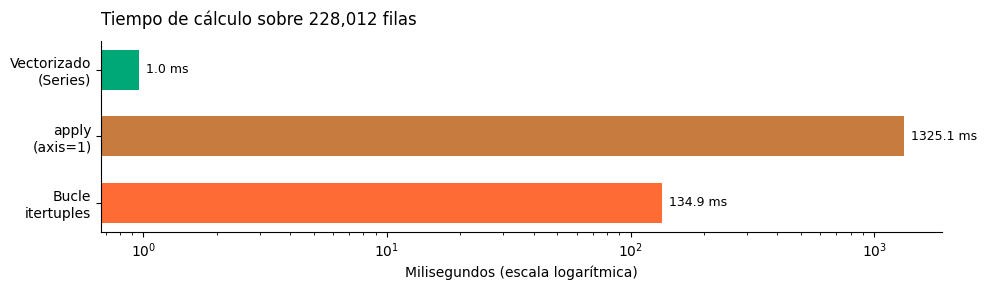

In [46]:
fig, ax = plt.subplots(figsize=(10, 3))
metodos = ["Bucle\nitertuples", "apply\n(axis=1)", "Vectorizado\n(Series)"]
tiempos = [t_loop * 1000, t_apply * 1000, t_vec * 1000]
barras = ax.barh(metodos, tiempos, color=[NARANJA, "#C77B3E", VERDE], height=0.6)
ax.bar_label(barras, fmt="%.1f ms", padding=5, fontsize=9)
ax.set_xlabel("Milisegundos (escala logarítmica)")
ax.set_xscale("log")
ax.set_title(f"Tiempo de cálculo sobre {len(base):,} filas",
             fontsize=12, loc="left", pad=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Qué muestra.** El resultado que importa es que `apply(axis=1)` sale **peor que el bucle explícito** que pretende reemplazar. Con `axis=1`, pandas arma un objeto `Series` por cada fila antes de pasarla a la función, y ese armado cuesta más que la división que se quería calcular.

`apply` sirve para lógica que no se puede expresar como operación de columna. Usarlo por comodidad sintáctica es más lento que escribir el bucle a mano, y bastante más lento que no iterar.

## 6.3 Auditoría: el pipeline no itera filas

El benchmark muestra el costo de iterar. Esta celda comprueba que el proyecto no lo hace, recorriendo el código fuente de los módulos de datos.

In [47]:
MODULOS_DATOS = ["ingesta_ocds.py", "consulta_proveedores.py", "transformacion.py",
                 "validacion.py", "calidad.py", "diagnostico.py", "utils.py"]
PATRONES = {
    "iterrows()": r"\.iterrows\(",
    "itertuples()": r"\.itertuples\(",
    "apply(axis=1)": r"\.apply\([^)]*axis\s*=\s*1",
}

hallazgos = []
for modulo in MODULOS_DATOS:
    ruta = Path(config.BASE_DIR) / modulo
    if not ruta.exists():
        continue
    texto = ruta.read_text(encoding="utf-8")
    # Se ignoran los comentarios para no contar las menciones explicativas
    codigo = "\n".join(l for l in texto.splitlines()
                       if not l.strip().startswith("#"))
    hallazgos.append({
        "Módulo": modulo,
        "Líneas": len(texto.splitlines()),
        **{p: len(re.findall(rx, codigo)) for p, rx in PATRONES.items()},
    })

auditoria = pd.DataFrame(hallazgos).set_index("Módulo")
total = int(auditoria[list(PATRONES)].to_numpy().sum())

display(tabla(auditoria, "Auditoría de iteración fila por fila", decimales=0))
print(f"Iteraciones fila por fila en la ruta de datos: {total}")

,Líneas,iterrows(),itertuples(),apply(axis=1)
Módulo,,,,
ingesta_ocds.py,395,0,0,0
consulta_proveedores.py,317,0,0,0
transformacion.py,498,0,0,0
validacion.py,370,0,0,0
calidad.py,420,0,0,0
diagnostico.py,297,0,0,0
utils.py,312,0,0,0


Iteraciones fila por fila en la ruta de datos: 0


**Qué muestra.** Cero iteraciones fila por fila en los módulos que procesan datos.

**Dónde sí quedan bucles, y por qué no son lo mismo.** `optimizar_memoria()` recorre las columnas del DataFrame, no sus filas: son unas veinte iteraciones sobre metadatos, no cientos de miles sobre datos, y cada columna necesita una decisión de tipo distinta. Los módulos de red recorren páginas de una API, donde el costo lo domina la latencia HTTP. Y en la aplicación quedan bucles de renderizado sobre unas pocas decenas de filas ya filtradas, que no calculan nada.

---
# 7. El pipeline completo

## Qué se va a hacer

Encadenar las etapas en el mismo orden en que corren en producción dentro de `diagnostico.py`: validar los insumos, integrar, transformar y validar la salida.

El orden importa. Se mide antes de validar, y se valida antes y después de transformar, porque integrar datos que ya vienen mal solo propaga el error al maestro y lo vuelve más difícil de rastrear.

In [48]:
reporte_final = Reporte("notebook_pipeline")
t0 = time.perf_counter()

demanda_v = validacion.validar(demanda, validacion.ESQUEMA_DEMANDA, reporte_final)
densidad_v = validacion.validar(densidad, validacion.ESQUEMA_DENSIDAD, reporte_final)
maestro_p = construir_maestro(demanda_v, densidad_v, convocatorias)
maestro_p = transformacion.transformar(maestro_p, ocds, reporte_final)
maestro_p = validacion.validar(maestro_p, validacion.ESQUEMA_MAESTRO, reporte_final)

duracion = time.perf_counter() - t0

etapas = pd.DataFrame([
    {"Etapa": "1. Validación de insumos",
     "Resultado": f"{len(demanda_v):,} categorías válidas"},
    {"Etapa": "2. Integración",
     "Resultado": f"{maestro_p.shape[1]} columnas en el maestro"},
    {"Etapa": "3. Transformación",
     "Resultado": "enriquecer + binning + escalar + optimizar"},
    {"Etapa": "4. Validación de salida",
     "Resultado": f"{len(maestro_p):,} categorías publicables"},
    {"Etapa": "Duración total", "Resultado": f"{duracion:.2f} segundos"},
]).set_index("Etapa")

tabla(etapas, "Pipeline ejecutado de punta a punta", ancho_col="290px")

2026-07-30 01:02:49 | INFO    | validacion | REGLAS | dataset=demanda_por_categoria | columnas_con_esquema=3


2026-07-30 01:02:49 | INFO    | validacion | REGLAS | dataset=demanda_por_categoria | columna=cubso_descripcion | tipo=string[pyarrow] | nullable=False | checks=str_length, categoria_unica


2026-07-30 01:02:49 | INFO    | validacion | REGLAS | dataset=demanda_por_categoria | columna=demanda_soles | tipo=float64 | nullable=False | checks=greater_than_or_equal_to, less_than


2026-07-30 01:02:49 | INFO    | validacion | REGLAS | dataset=demanda_por_categoria | columna=n_procesos | tipo=int64 | nullable=False | checks=greater_than


2026-07-30 01:02:49 | WARNING | validacion | VALIDACION | dataset=demanda_por_categoria | estado=CON_FALLOS | reglas_fallidas=4 | filas_afectadas=4 | pct=0.01


...

2026-07-30 01:02:50 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=convocatorias_vigentes | tipo=Int64 | nullable=True | checks=greater_than_or_equal_to


2026-07-30 01:02:50 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=competencia_vigente | tipo=float64 | nullable=True | checks=greater_than_or_equal_to


2026-07-30 01:02:50 | INFO    | validacion | REGLAS | dataset=maestro_oportunidades | columna=banda_competencia | tipo=string[pyarrow] | nullable=False | checks=isin


2026-07-30 01:02:50 | INFO    | validacion | VALIDACION | dataset=maestro_oportunidades | estado=OK | filas=30705 | reglas_fallidas=0


,Resultado
Etapa,
1. Validación de insumos,"30,705 categorías válidas"
2. Integración,37 columnas en el maestro
3. Transformación,enriquecer + binning + escalar + optimizar
4. Validación de salida,"30,705 categorías publicables"
Duración total,0.58 segundos


In [49]:
# La tabla que alimenta el radar se arma SOBRE LAS CATEGORÍAS APTAS. Sin el
# piso de mercado el top se llena de compras únicas cuyo adjudicatario salió
# del registro: cero competencia porque el mercado no existe, no porque esté
# desatendido.
aptas = maestro_p["apto_para_ranking"].astype("object").fillna(False).astype(bool)

columnas_app = [c for c in
                ["cubso_descripcion", "indice_oportunidad", "potencial_mercado",
                 "demanda_soles", "competencia_vigente", "salieron_del_registro",
                 "ticket_uit", "banda_ticket", "mes_pico",
                 "convocatorias_vigentes", "banda_competencia"]
                if c in maestro_p.columns]

final = maestro_p[aptas].nlargest(15, "indice_oportunidad")[columnas_app].copy()
if "mes_pico" in final.columns:
    final["mes_pico"] = final["mes_pico"].map(
        lambda m: NOMBRE_MES[int(m) - 1] if pd.notna(m) else "—")
final = final.set_index("cubso_descripcion")
final.index.name = "Categoría CUBSO"
nombres = ["Índice", "Potencial", "Demanda (S/)", "Siguen habilitados",
           "Salieron del registro", "Ticket (UIT)", "Banda de ticket",
           "Mes pico", "Llamados abiertos", "Competencia"]
final.columns = nombres[:len(final.columns)]

print(f"Categorías aptas para el ranking: {int(aptas.sum()):,} "
      f"de {len(maestro_p):,}\n")
barra_color(final, "Índice", "Resultado final: lo que consume la Data App",
            decimales=1, color=VERDE)

Categorías aptas para el ranking: 12,386 de 30,705



,Índice,Potencial,Demanda (S/),Siguen habilitados,Salieron del registro,Ticket (UIT),Banda de ticket,Mes pico,Llamados abiertos,Competencia
Categoría CUBSO,,,,,,,,,,
SUSCRIPCION A BASE DE DATOS DE INFORMACION FINANCIERA Y SERVICIOS RELACIONADOS,74.3,74.3,"850,323.5",1.0,0.0,7.4,Contratación menor (≤8 UIT),Ene,0,Poca competencia (1-2)
JUEGO DE SALVAMENTO PARA SUBESTACION ELECTRICA X 7 PIEZAS,73.8,73.8,"124,850.0",0.0,3.0,5.7,Contratación menor (≤8 UIT),Ago,0,Sin adjudicatario vigente
TALLER EN TEMAS DE FORMACION DE LIDERES,73.7,73.7,"117,387.0",0.0,2.0,5.3,Contratación menor (≤8 UIT),Nov,0,Sin adjudicatario vigente
SERVICIO DE PUBLICACION DE ARTICULOS CIENTIFICOS EN REVISTA INTERNACIONAL,73.3,73.3,"565,007.3",1.0,0.0,2.1,Contratación menor (≤8 UIT),Ago,0,Poca competencia (1-2)
SERVICIO LEGAL EN TEMAS DE USO DE MARCA Y LOGOTIPO,72.2,72.2,"377,053.5",1.0,0.0,6.9,Contratación menor (≤8 UIT),Mar,0,Poca competencia (1-2)
DIPLOMADO EN ADMINISTRACION Y GESTION PUBLICA,71.6,71.6,"291,029.9",1.0,1.0,6.6,Contratación menor (≤8 UIT),Dic,0,Poca competencia (1-2)
ELABORACION DE EXPEDIENTE TECNICO RELACIONADOS A CONSTRUCCION DEL CANAL DE IRRIGACION DE LOS CASERIOS,70.9,70.9,"217,690.0",1.0,0.0,7.9,Contratación menor (≤8 UIT),Jul,0,Poca competencia (1-2)
SERVICIO DE APOYO P/ATENCION EN MESA DE AYUDA-DOCUMENTACION PROCESO ATENCION,70.8,70.8,"214,621.2",1.0,0.0,6.5,Contratación menor (≤8 UIT),Abr,0,Poca competencia (1-2)
PROTESIS DE RODILLA CON SISTEMA ROTACIONAL MEDIANO,70.5,70.5,"189,596.5",1.0,0.0,5.8,Contratación menor (≤8 UIT),Jun,0,Poca competencia (1-2)


**Qué muestra.** Esta es la tabla que alimenta la pantalla del radar. Cada columna es el producto de una etapa distinta del wrangling: el índice viene del escalado, la banda de ticket del binning, el mes pico de la agregación temporal, y los llamados abiertos del cruce con el monitor de convocatorias.

In [50]:
ruta = reporte_final.guardar()
contenido = json.loads(ruta.read_text(encoding="utf-8"))

df_rep = pd.DataFrame(contenido["secciones"]["comparacion_escalado"]).T
df_rep.index.name = "Algoritmo"

print(f"Reporte de la corrida: {ruta.name}\n")
tabla(df_rep, "Comparación de escalados registrada en el reporte", decimales=4)

Reporte de la corrida: notebook_pipeline_20260730_010249.json



,min,p50,p90,max,pct_bajo_0.05,pct_negativo
Algoritmo,,,,,,
minmax_crudo,0.0000,0.0001,0.0013,1.0000,99.0000,—
minmax_sobre_log,0.0000,0.5534,0.6983,1.0000,0.0000,—
zscore_sobre_log,-5.9651,-0.1648,1.3543,4.5167,—,56.9000
elegido,minmax_sobre_log,minmax_sobre_log,minmax_sobre_log,minmax_sobre_log,minmax_sobre_log,minmax_sobre_log


**Qué muestra.** El reporte JSON de cada corrida guarda la comparación de escalados con sus números. Eso convierte la decisión de diseño en algo auditable: no hay que creer en la elección, se puede revisar el archivo de cualquier corrida y ver los percentiles que la sustentan.

---
# 8. Conclusiones

Cada técnica del Tema 4 se aplicó sobre los datos del proyecto, no sobre un dataset de ejemplo. Lo que sigue es lo que cada una dejó ver, con los números de esta corrida.

## 8.1 Qué mostró cada técnica

### Con las métricas de calidad vimos que el problema no estaba donde lo buscábamos

El detalle OCDS puntúa 94.20 sobre 100, la demanda por categoría 99.99, el padrón de proveedores 97.72 y la densidad 100.00.

Tres resultados que no esperábamos.

La validez de `proveedor_id` es 77.41 %. De 221 950 identificadores evaluados, 50 141 no tienen forma de RUC de once dígitos. No son errores de carga: son consorcios y personas naturales, que se identifican de otra manera. El dato define el universo que se puede contrastar contra el padrón oficial del OECE, y esa brecha reaparece en la cobertura del padrón (48 981 adjudicatarios con RUC, 48 981 fichas descargadas, 100 %).

Hay 33 677 registros con monto y sin categoría CUBSO, el 14.77 % del detalle. Ese número reaparece exacto más adelante: de 228 012 filas de detalle, solo 194 335 llegan a formar categorías. La métrica de consistencia anticipó una pérdida que la agregación después materializó.

La exactitud obligó a separar dos criterios que se confunden con facilidad. Por rango intercuartílico salen 33 161 valores atípicos, el 14.54 %, con un límite superior de S/ 949 092. Por cota fija de unidad salen 6, el 0.0026 %. Si hubiéramos limpiado los atípicos con el criterio estadístico habitual, habríamos borrado treinta y tres mil contratos grandes que son reales, y con ellos buena parte del mercado de obras.

La actualidad es el único indicador en rojo. El archivo llega hasta el 31 de diciembre de 2025 y arrastra 210 días de desfase contra un umbral propio de 120. La descarga masiva OCDS se publica por año cerrado, así que el desfase es estructural y no se arregla corriendo la ingesta otra vez. Es la razón por la que el proyecto agregó el monitor de convocatorias vigentes contra la API en vivo.

### Con las variables derivadas descartamos un indicador y encontramos el que sí mide

Esta es la sección donde el proyecto cambió de diseño, y el cambio lo forzó la medición.

El indicador original era un cociente de saturación: adjudicados de la categoría sobre habilitados del capítulo. Medido con la capa completa descargada, su mediana es 0.0000 y su máximo 0.1774. Ninguna categoría llega a la quinta parte de los habilitados de su capítulo, y su valor modal se repite en el 61.49 % del catálogo. Un índice construido sobre esa columna valdría casi lo mismo en todas las filas.

La causa es una asimetría de grano, no un error de cálculo: cuatro capítulos del RNP reparten su conteo entre 30 701 categorías CUBSO. Arreglarlo pediría habilitados por categoría, desagregación que el RNP no publica porque la habilitación se otorga por capítulo.

La salida fue cambiar la pregunta por una que la fuente sí contesta con grano homogéneo. En lugar de comparar los ganadores de la categoría contra los habilitados de todo el capítulo, se comparan los ganadores de la categoría contra su propio estado de habilitación. Eso es `competencia_vigente`: el cruce por RUC del detalle OCDS contra la Ficha Única del Proveedor, que va de 0 a 1 334 competidores y contesta lo que ninguna de las dos fuentes contesta sola.

`origen_espacio` deja a la vista hasta dónde llega el cruce: 28 275 categorías usan el dato real y 2 430 caen al sucedáneo de concentración, porque sus adjudicatarios son consorcios o personas naturales sin RUC de once dígitos. Esas 2 430 se etiquetan "Competencia no determinada" y no como mercado vacío.

El hallazgo que justifica la descarga completa del padrón: **852 categorías tuvieron ganadores y hoy no tienen ninguno habilitado**, por S/ 1 440.6 millones de demanda acumulada. No es que nadie compita ahí: es que quienes competían salieron del registro. Van a un panel aparte ordenado por demanda.

### Con las agregaciones vimos que la demanda del Estado es demanda de obras

Las ocho categorías de mayor demanda son seguridad y vigilancia, mantenimiento de carreteras, construcción de carreteras, infraestructura de salud y cuatro de infraestructura educativa y vial. La primera concentra S/ 8 156 millones en 1 818 procesos, repartidos entre 624 proveedores y 422 entidades compradoras.

Ninguna de ellas es accesible para el usuario al que apunta el radar. Ese contraste, entre dónde está la plata y dónde puede entrar una empresa chica, es lo que justifica que el índice no sea un ranking de demanda.

### Con la agregación temporal vimos que el pico de 2025 no era estacionalidad

Esta técnica cambió una conclusión que ya dábamos por buena.

Medida en soles, la estacionalidad parecía inestable: el máximo caía en octubre en 2024 y en setiembre en 2025, con 58 253 millones concentrados en ese mes, el 26.9 % del año. Al abrir la distribución apareció la explicación. La mediana de setiembre es casi igual a la de agosto, 1.13 veces, mientras que el percentil 99 es catorce veces mayor. El exceso vive entero en la cola: contratos de gran envergadura, del tramo que el radar excluye por banda de ticket.

Medida en cantidad de convocatorias accesibles, por debajo del percentil 90 de los montos (S/ 1.63 millones, que cubre el 90 % de las adjudicaciones), la estacionalidad sí es clara y se repite. El último trimestre concentra 31.9 % en 2024 y 30.9 % en 2025 frente al 25 % de un reparto plano, y la diferencia entre el mes más alto y el más bajo va de 1.81 a 2.69 veces según el año.

El mismo fenómeno explica el salto entre años. De 2024 a 2025 las adjudicaciones crecieron 16.3 % pero el monto creció 110.8 %, con el ticket medio pasando de S/ 1.09 a S/ 1.97 millones. No hubo el doble de compras: hubo compras mucho más grandes.

Para el usuario del radar la lectura accionable es la segunda. Un proveedor pequeño enfrenta un mercado que se contrae en enero y febrero y se expande de octubre a diciembre, y como la inscripción en el RNP tiene plazos de trámite, esperar a ver las convocatorias de noviembre para empezar el registro llega tarde.

### Con el piso de mercado descubrimos que el índice premiaba mercados inexistentes

Sin un piso de volumen, el índice premia mercados vacíos por diminutos. Una categoría donde el Estado gastó S/ 44 000 en dos años no tiene competencia porque no vale la pena competir ahí, no porque haya una oportunidad desatendida.

El criterio que separa las dos cosas es la recurrencia y no el monto. La mediana de procesos por categoría es exactamente 1, así que exigir al menos 2 procesos separa mercados de compras aisladas. Con ese filtro más un piso monetario suave de 20 UIT acumuladas, quedan 12 386 categorías aptas de 30 705.

Las 18 319 descartadas no se borran del dataset: se marcan con `apto_para_ranking = False`. La decisión de alcance queda visible y reversible en lugar de esconderse en una fila que desapareció.

### Con el binning vimos que dos tercios del catálogo están al alcance de una MYPE

Anclado en la UIT 2026 de S/ 5 500, el reparto queda en 5 138 categorías de contratación menor, 15 960 accesibles entre 8 y 50 UIT, 5 931 intermedias y 3 680 grandes. Sumando las dos primeras, 21 098 de 30 709 categorías, el 68.7 % del catálogo, tienen un ticket promedio por debajo de 50 UIT.

Es el número que contradice la intuición de que contratar con el Estado es cosa de empresas grandes. El monto está concentrado arriba, pero la cantidad de categorías está concentrada abajo.

La técnica se usó en sus dos formas por razones distintas. `pd.cut` con cortes fijos para las bandas de ticket, porque el umbral de 8 UIT viene de la ley y tiene que significar lo mismo el año que viene. `pd.qcut` para los cuartiles de demanda, porque ahí la pregunta es relativa y un corte fijo en soles envejecería con la inflación.

### Con el escalado vimos que sin logaritmo el índice no ordenaba nada

Min-Max crudo deja el 99.6 % de las categorías por debajo de 0.05. Casi todo el catálogo se reparte el 5 % inferior de la escala, y en ese tramo un índice no distingue una categoría de otra. Aplicando `log1p` antes, ninguna categoría queda en ese tramo. Z-Score sobre logaritmo aguanta bien la cola pero devuelve 56.9 % de valores negativos, y un puntaje de menos uno no se publica en un tablero.

El efecto sobre el resultado es medible: la posición media de una categoría se desplaza casi quince mil puestos al pasar de ordenar por demanda a ordenar por índice, y de las veinte categorías de mayor demanda, ninguna sobrevive en el top 20 del índice. Las veinte que lo encabezan entran gracias a la transformación.

### Con la validación automatizada vimos que los errores se atrapan antes del tablero

Sobre un dataset al que se le inyectaron cuatro errores a propósito, Pandera devolvió los cuatro en una sola pasada, con fila, columna, regla incumplida y valor que falló: un monto negativo, un índice de 145 sobre una escala de 100, una categoría duplicada y una banda de competencia fuera del catálogo. Los casos fallidos se escriben a `reports/` y no al log, porque un caso fallido es un dato y no un evento de proceso.

Sobre los datos reales, la validación de insumos apartó 4 categorías de 30 709 en la demanda, el 0.01 %, y ninguna en la densidad. Las siete reglas de negocio dieron cero violaciones. Dos de ellas son nuevas y vigilan el diseño de esta corrida: que los habilitados vigentes nunca superen a los ganadores históricos (detecta un merge que duplique filas) y que la bandera de mercado desierto siga siendo coherente con las dos columnas que la definen.

### Con el downcasting vimos que el costo estaba en el texto repetido

El detalle OCDS pasa de 100.5 a 59.6 MB, un ahorro del 40.6 % sobre ocho columnas. Siete de esas ocho son de texto que se repite miles de veces, como el nombre de la entidad compradora o la descripción de la categoría, y el ahorro viene de convertirlas a `category`: cada valor se guarda una sola vez y en las filas queda un código entero. La única columna numérica que aportó fue `n_proveedores_award`, que nunca pasa de 40 y llegaba como `int64`.

### Con la vectorización vimos que `apply` es peor que el bucle que pretende reemplazar

El mismo cálculo sobre 228 012 filas toma 76.27 ms con un bucle `itertuples`, 935.51 ms con `apply(axis=1)` y 0.99 ms vectorizado. Los tres devuelven el mismo resultado.

Que la operación de columna gane no es el hallazgo. El hallazgo es que `apply(axis=1)` sale 12.3 veces peor que el bucle explícito que pretende reemplazar: con `axis=1`, pandas arma un objeto `Series` por cada fila antes de pasarla a la función, y ese armado cuesta más que la división que se quería calcular.

La auditoría sobre el código fuente confirma que la ruta de datos no itera: cero apariciones de `iterrows()`, `itertuples()` y `apply(axis=1)` en las 2 414 líneas de los siete módulos que procesan datos.

## 8.2 Las cinco preguntas de negocio, contestadas

**Q1. ¿Qué categorías CUBSO concentran la mayor demanda histórica del Estado?**
Servicio de seguridad y vigilancia encabeza con S/ 8 156 millones en 1 818 procesos, seguida de mantenimiento y construcción de carreteras con S/ 7 621 y S/ 7 437 millones. Las ocho primeras son obras y servicios de infraestructura. La respuesta se construye en la sección 3.3 con una sola operación `groupby` sobre 194 335 filas de detalle.

**Q2. ¿Qué categorías presentan alta demanda y baja cantidad de proveedores adjudicados?**
La banda de competencia reparte el catálogo en 852 categorías sin ningún adjudicatario vigente, 20 868 con poca competencia (1 o 2 habilitados), 3 845 con competencia media (3 a 5), 2 710 disputadas (más de 5) y 2 430 sin dato porque sus adjudicatarios no cruzan contra el padrón. La variable `espacio_mercado` pesa 45 % del potencial y se apoya en el cruce real en el 92.1 % de las categorías. Las 852 sin adjudicatario vigente son la respuesta más fuerte a esta pregunta: rubros con demanda y sin nadie en carrera, por S/ 1 440.6 millones.

**Q3. ¿Cómo varía la demanda por año, entidad contratante y rango de monto?**
Por año, el monto creció 110.8 % entre 2024 y 2025 mientras las adjudicaciones crecieron 16.3 %: el crecimiento es de tamaño de contrato, no de cantidad de compras. Por mes, el último trimestre concentra alrededor del 31 % de las convocatorias accesibles frente al 25 % de un reparto plano. Por rango de monto, el binning reparte el catálogo en cuatro bandas ancladas en la UIT, con el 68.7 % por debajo de 50 UIT. Secciones 3.3, 3.4 y 3.5.

**Q4. ¿Cuál es el monto promedio por proceso en cada categoría y qué nivel de acceso representa para una MYPE?**
`ticket_uit` traduce el ticket promedio a la unidad de la normativa y `banda_ticket` lo convierte en una etiqueta que el usuario puede filtrar. El nivel de acceso entra al índice como factor multiplicativo, con valores de 1.00 para contratación menor y 0.10 para la banda grande. Esa decisión es la que hace que el ranking final lo encabecen categorías de ticket bajo: las quince primeras del índice caen todas en contratación menor, con tickets de entre 2.10 y 7.92 UIT. Secciones 3.2, 3.5 y 4.1.

**Q5. ¿Qué cobertura tiene la identificación de proveedores y qué registros requieren validación contra el padrón oficial?**
El 77.41 % de los identificadores tiene forma de RUC. Los 50 141 restantes corresponden a consorcios y personas naturales, y quedan fuera de la capa de habilitados por diseño de la fuente. Sobre el universo consultable la cobertura es total: 48 981 adjudicatarios con RUC y 48 981 fichas descargadas, de las cuales 43 203 están habilitadas vigentes. Secciones 2.3 y 2.1.

## 8.3 Alcance de la medición

Tres precisiones sobre qué mide el radar y qué no, porque condicionan cómo se leen las cifras de arriba.

**La demanda medida es la demanda clasificada.** El 14.77 % de las adjudicaciones llega sin categoría CUBSO, y esos montos no entran en ninguna categoría del radar. El total del catálogo queda por debajo del gasto público real. La métrica de consistencia lo detecta y lo cuantifica en cada corrida: de 228 012 filas de detalle, 194 335 llegan a formar categorías.

**La habilitación se otorga por capítulo, no por categoría.** El RNP habilita en bienes, servicios, ejecución de obras o consultoría de obras, así que `habilitados_capitulo` toma cuatro valores y funciona como contexto del sector. Esta es la razón por la que la señal del proyecto se construye sobre `competencia_vigente`, que compara los ganadores de cada categoría contra su propio estado de habilitación y por lo tanto tiene grano homogéneo. La medición que llevó a esa decisión está en la sección 3.2.

**El cruce cubre el 92.1 % del catálogo.** Las 2 430 categorías restantes tienen adjudicatarios que son consorcios o personas naturales sin RUC de once dígitos, formatos que el padrón del OECE no indexa. Esas categorías se etiquetan "Competencia no determinada" y su espacio de mercado sale del indicador sustituto. No se cuentan como mercado vacío: distinguir "no hay dato" de "no hay nadie" es lo que evita que el radar recomiende un rubro por una ausencia de información.

Sobre el universo que sí es consultable, la cobertura es total: 48 981 adjudicatarios con RUC y 48 981 fichas descargadas, con 43 203 habilitados vigentes. El pipeline calcula y reporta ese porcentaje en cada corrida porque de él depende la validez de la cifra de competencia.

### Decisiones de alcance que quedan a la vista

**El piso de mercado.** Los cortes de 2 procesos y 20 UIT acumuladas son una elección del equipo para separar mercados de compras aisladas, no un umbral normativo. Viven en `config.py`, la Data App permite desactivarlos y el reporte de cada corrida informa cuántas categorías quedaron afuera. Con otro umbral el ranking cambia, y por eso el parámetro es visible en lugar de estar escrito dentro de una función.

**La estacionalidad se mide donde hay serie.** La regla R7 exige seis meses de actividad además del 25 % de concentración, y con eso quedan 2 577 categorías marcadas. Las que tienen un único mes activo no se evalúan: un pico del 25 % en una categoría con cuatro meses de movimiento es compatible con un reparto plano, así que marcarlas sería reportar concentración donde solo hay bajo volumen.

**Los dos horizontes del tablero.** El radar histórico y el monitor de convocatorias responden preguntas distintas y por eso son dos pantallas. La descarga masiva OCDS se publica por año cerrado, lo que da un desfase estructural que la métrica de actualidad detecta y reporta: es exactamente el motivo por el que el proyecto agregó la consulta en vivo a la API de releases. El histórico dice dónde conviene prepararse; el monitor, qué está convocado en el momento de la consulta. La profundidad del monitor es un parámetro de corrida (`--paginas`), así que la cantidad de llamados que muestra depende de cuánto se recorra la API y no de una propiedad del mercado.

## 8.4 Tres hallazgos que solo aparecieron al medir

Una regla de negocio estaba mal planteada. Comparaba los proveedores adjudicados contra el número de procesos y marcaba 968 categorías como incoherentes. El error era conceptual: un proceso dividido en lotes emite varias adjudicaciones y puede repartirlas entre proveedores distintos, así que la cota correcta es la cantidad de filas de adjudicación, no la de procesos.

El índice de oportunidad, en su primera versión, ordenaba el ranking al revés de lo que el proyecto promete. La accesibilidad entraba como componente aditivo con 20 % de peso, y con esa fórmula arriba quedaban obras de saneamiento y carreteras de millones de soles, inalcanzables para el usuario al que apunta la herramienta. Convertirla en factor multiplicativo anclado en bandas UIT fue lo que puso al frente las categorías pequeñas y accesibles.

El indicador de competencia medía un cociente entre universos incompatibles. La saturación dividía una cuenta por categoría CUBSO entre una cuenta por capítulo RNP, y el resultado quedaba en el orden de 0.0001 para todo el catálogo con más de la mitad de las categorías empatadas en el mismo valor. Se reemplazó por `competencia_vigente`, que compara los ganadores de la categoría contra su propio estado de habilitación y por lo tanto tiene grano homogéneo en numerador y denominador. El cambio arrastró la etiqueta de mercado: la clasificación 2x2 de demanda por saturación dejaba el top del ranking rotulado "Nicho menor", que en pantalla se lee como un error, y se reemplazó por una banda de un solo eje con cortes en 0, 2 y 5 competidores.

Ninguno de los tres se habría detectado leyendo el código: los tres aparecieron al mirar los números que el pipeline producía. Es el argumento a favor de haber medido antes de publicar el tablero.

---
# 9. Lo que se decidió no incluir

El Tema 4 pide un repertorio de técnicas más amplio que el que este dataset justifica. Enumerarlas y aplicarlas todas habría llenado el notebook de celdas sin lectura. Lo que sigue es qué se dejó afuera y por qué, que es una decisión de alcance y no un olvido.

**Imputación de valores faltantes.** No se imputa nada, y es deliberado. Los faltantes de este proyecto no son ruido de medición: las 33 677 adjudicaciones sin categoría CUBSO faltan porque la entidad compradora no clasificó el ítem, y los 50 141 identificadores sin forma de RUC faltan porque son consorcios y personas naturales. Rellenar la categoría con la moda o el monto con la mediana inventaría demanda estatal que nunca existió. La decisión es declarar la pérdida y medir su tamaño.

**Tratamiento de valores atípicos.** Tampoco se recortan. La métrica de exactitud cuenta 33 161 atípicos por rango intercuartílico, el 14.54 % del detalle, y son contratos reales: obras viales, medicamentos, combustible. Descartarlos dejaría al radar sin las categorías que más presupuesto mueven. La cola se comprime con logaritmo antes de escalar, que conserva el orden en lugar de borrar filas.

**Codificación de variables categóricas.** One-hot y label encoding existen para alimentar modelos, y acá no hay modelo. El proyecto es descriptivo por decisión de alcance: produce un índice con pesos declarados, no una predicción entrenada. Convertir `capitulo_rnp` en cuatro columnas binarias no tendría consumidor.

**Reducción de dimensionalidad.** Mismo motivo. El maestro tiene 37 columnas, cada una con un nombre que significa algo para el usuario del tablero. Un PCA sobre eso devolvería componentes que nadie puede interpretar en una pantalla que existe para explicar por qué una categoría está donde está.

**Muestreo y balanceo de clases.** No hay clases a balancear porque no hay clasificación supervisada. La etiqueta `banda_competencia` es el resultado de cortes explícitos declarados en `config.py`, no de un entrenamiento.

**Detección de duplicados exactos como limpieza.** La unicidad se mide (7 113 filas con clave de negocio repetida en el detalle) pero no se deduplica. Un mismo proceso adjudica la misma categoría al mismo proveedor en varios ítems, y cada ítem es un monto distinto que hay que sumar. Borrar esas filas restaría demanda real.

Una última observación sobre el alcance del notebook mismo: mide y transforma sobre los datos que la ingesta ya dejó en disco. La descarga, los reintentos ante HTTP 429 y el sistema de checkpoints de las 48 981 fichas viven en los módulos de ingesta y no se reproducen acá, porque una celda que consulta una API en vivo no es reejecutable en una defensa.